# 03 — LP Optimization & Results

Goals:
- Define battery parameters
- Solve LP optimization for each day in the dataset
- Compare three scenarios: fixed tariff / dynamic no battery / dynamic + battery
- Visualize: price curve + charge/discharge schedule for a representative day
- Compute yearly savings in EUR

## 0. Imports & configuration

In [2]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

_nb_dir = Path(globals()['__vsc_ipynb_file__']).parent
_src    = (_nb_dir / '../src').resolve()
sys.path.insert(0, str(_src))

from battery_utils import optimize_day, threshold_strategy, backtest

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

DATA = '../../Data/'

# ── Household consumption ──────────────────────────────────────────────────────
ANNUAL_KWH = 3500   # target annual consumption (kWh/year)
                    # 3500 = Belgian average household (Fluvius 2023)
                    # change to match your household before running backtests

# ── Battery parameters — BYD LFP 10 kWh ──────────────────────────────────────
battery = {
    "name":    "BYD LFP 10 kWh",
    "S_max":   10.0,   # total capacity (kWh)
    "S_min":    1.0,   # minimum SOC = 10% of capacity; protects against deep discharge
    "P_max":    5.0,   # max charge/discharge power (kW)
    "eta_c":    0.975, # charge efficiency (grid → battery)
    "eta_d":    0.975, # discharge efficiency (battery → load); eta_rt = eta_c * eta_d ≈ 0.95
    "S_init":   5.0,   # starting state of charge (50%)
    "deg_cost": 0.02,  # degradation cost EUR/kWh (NREL 2023, LFP residential)
}

S_MAX  = battery["S_max"]
S_MIN  = battery["S_min"]
P_MAX  = battery["P_max"]
ETA_C  = battery["eta_c"]
ETA_D  = battery["eta_d"]
S_INIT = battery["S_init"]
DEG    = battery["deg_cost"]

print(f"Household: {ANNUAL_KWH} kWh/year")
print(f"Battery  : {battery['name']}")
print(f"Capacity : {S_MAX} kWh  |  Min SOC: {S_MIN} kWh ({S_MIN/S_MAX:.0%})  |  Power: {P_MAX} kW")
print(f"η_charge : {ETA_C}  |  η_discharge: {ETA_D}  |  η_roundtrip: {ETA_C * ETA_D:.4f}")
print(f"Degradation: {DEG} EUR/kWh")
print(f"src path : {_src}")

Household: 3500 kWh/year
Battery  : BYD LFP 10 kWh
Capacity : 10.0 kWh  |  Min SOC: 1.0 kWh (10%)  |  Power: 5.0 kW
η_charge : 0.975  |  η_discharge: 0.975  |  η_roundtrip: 0.9506
Degradation: 0.02 EUR/kWh
src path : C:\Users\ummsa\DataScientist_Syntra\Stage\DinamischeTarief\battery-optimization-belgium\optimization\src


## 1. Load data

In [3]:
# ── Load cleaned data prepared by 02_eda.ipynb ────────────────────────────────
# Run 02_eda.ipynb first to generate Data/prepared/*.csv
PREPARED = '../../Data/prepared/'

prices = pd.read_csv(PREPARED + 'prices_clean.csv', index_col=0, parse_dates=True)
prices.index = prices.index.tz_convert('Europe/Brussels')

load = pd.read_csv(PREPARED + 'load_clean.csv', index_col=0, parse_dates=True)

print(f"Prices: {prices.index.min().date()} → {prices.index.max().date()}  ({len(prices):,} hrs)")
print(f"Load:   {load.index.min().date()} → {load.index.max().date()}  ({len(load):,} hrs)")

Prices: 2022-01-01 → 2025-12-30  (35,040 hrs)
Load:   2022-01-01 → 2025-12-30  (35,040 hrs)


## 1b. Load scaling — synthetic H0 → real kWh

Currently using the **H0 synthetic profile** (relative units, not real kWh).  
When real consumption data arrives → set `USE_REAL_LOAD = True` and provide the file path.

In [4]:
# ── Switch here when real data arrives ────────────────────────────────────────
USE_REAL_LOAD  = False
REAL_LOAD_PATH = '../../Data/real_consumption.csv'  # index=timestamp, col=consumption (kWh)

if USE_REAL_LOAD:
    # Real data: load as-is (already in kWh — no scaling needed)
    load = pd.read_csv(REAL_LOAD_PATH, index_col=0, parse_dates=True)
    load.columns = ['consumption']
    print(f"Mode: real data from {REAL_LOAD_PATH}")
else:
    # Synthetic H0: load_clean.csv was saved at 3500 kWh/year baseline in 02_eda.ipynb.
    # Rescale to ANNUAL_KWH so the results reflect the target household size.
    BASE_KWH = 3500
    if ANNUAL_KWH != BASE_KWH:
        load['consumption'] = load['consumption'] * (ANNUAL_KWH / BASE_KWH)
    print(f"Mode: synthetic H0 scaled to {ANNUAL_KWH} kWh/year")

actual = load[load.index.year == 2022]['consumption'].sum()
print(f"Annual total (2022): {actual:.0f} kWh")

Mode: synthetic H0 scaled to 3500 kWh/year
Annual total (2022): 3500 kWh


## 2. LP solver — single day

Baseline (no battery)             0.8731
                                      LP  Threshold
----------------------------------------------------
Grid bill (cost_electricity)      0.2477     0.3149
Battery wear (cost_degradation)    0.1124     0.1559
Net saving (saving_net)           0.5130     0.4023
Net saving (%)                     58.8%      46.1%


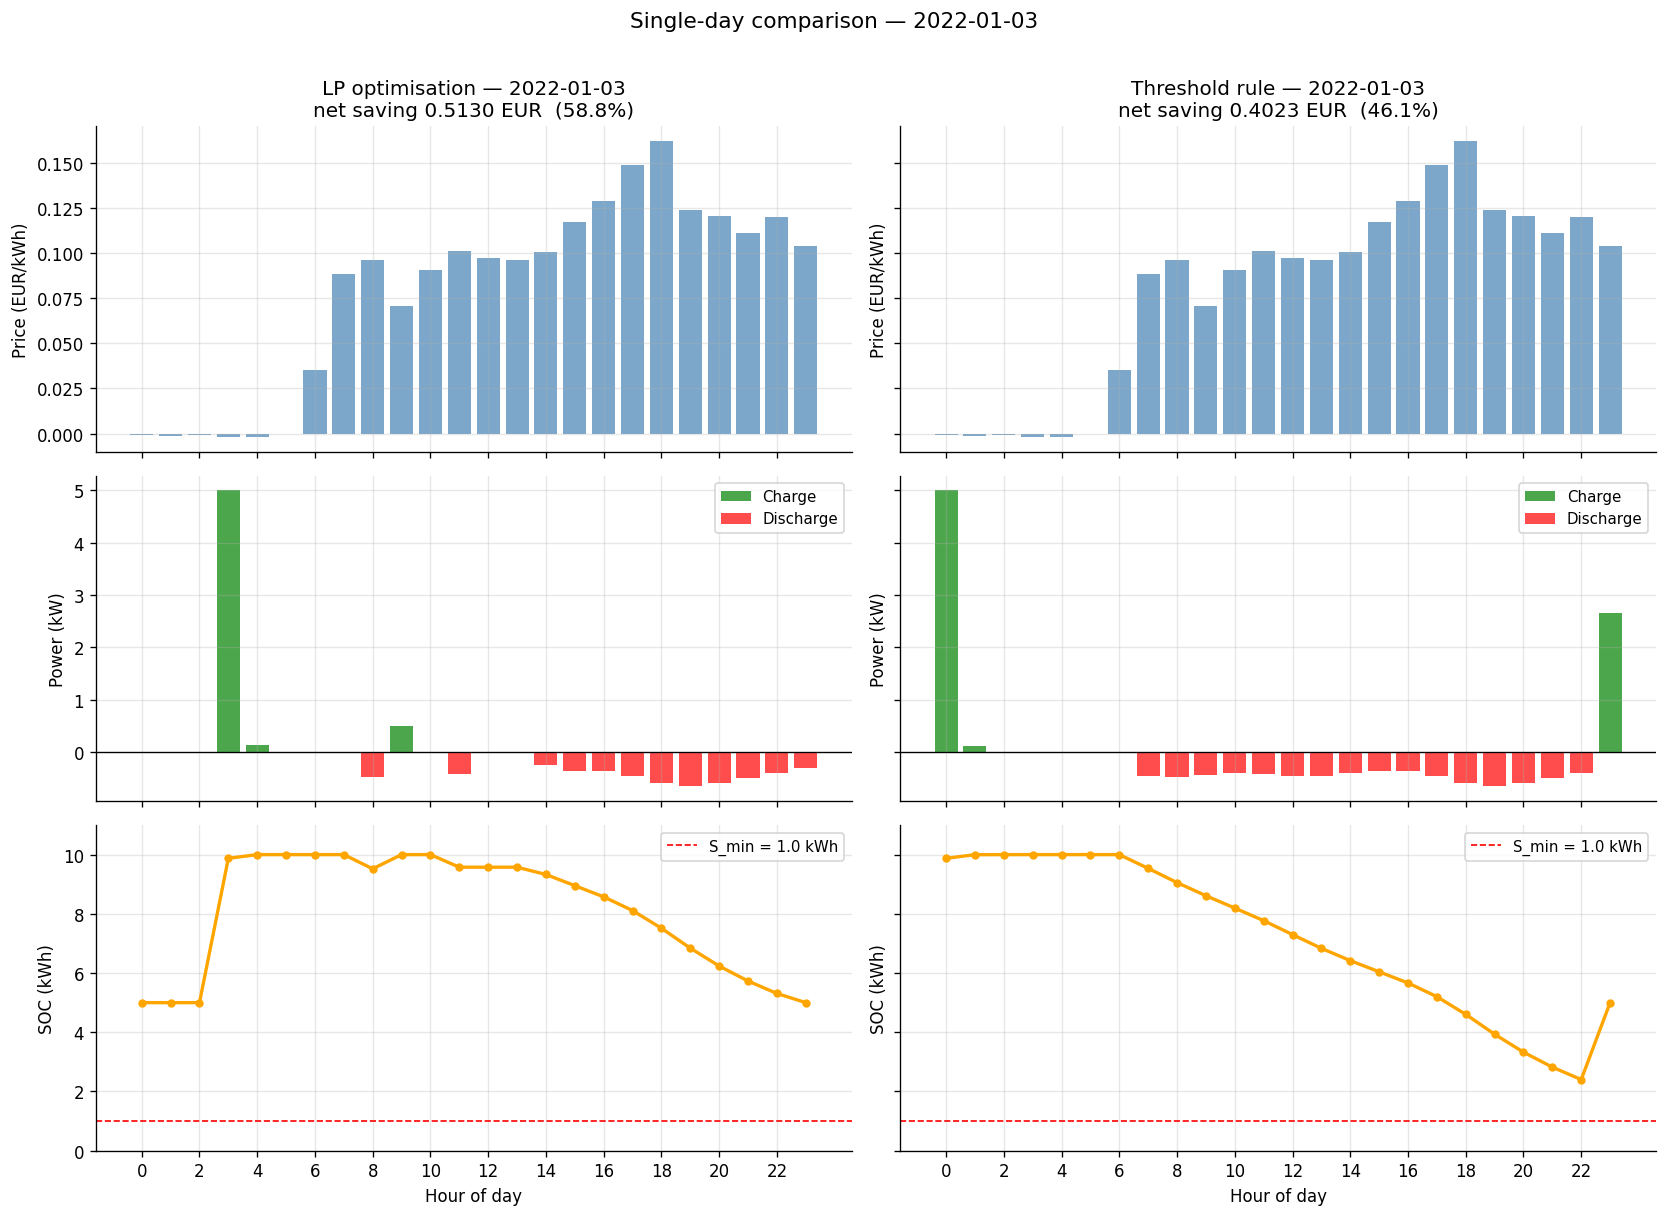

In [5]:
# ── Single-day demo: 2022-01-03 (a typical winter weekday) ───────────────────
demo_date = '2022-01-03'

p_day = prices[prices.index.date == pd.Timestamp(demo_date).date()]['price_eur_kwh'].values
l_day = load[load.index.date == pd.Timestamp(demo_date).date()]['consumption'].values

res_lp   = optimize_day(p_day, l_day, S_MAX, P_MAX, ETA_C, ETA_D, S_INIT, cyclic=True, binary=True, deg_cost=DEG, S_min=S_MIN)
res_rule = threshold_strategy(p_day, l_day, S_MAX, P_MAX, ETA_C, ETA_D, S_INIT, cyclic=True, deg_cost=DEG, S_min=S_MIN)
cost_base = float(np.dot(p_day, l_day))

print(f"{'Baseline (no battery)':30s}  {cost_base:8.4f}")
print(f"{'':30s}  {'LP':>8}  {'Threshold':>9}")
print("-" * 52)
print(f"{'Grid bill (cost_electricity)':30s}  {res_lp['cost_electricity']:8.4f}  {res_rule['cost_electricity']:9.4f}")
print(f"{'Battery wear (cost_degradation)':30s}  {res_lp['cost_degradation']:8.4f}  {res_rule['cost_degradation']:9.4f}")
print(f"{'Net saving (saving_net)':30s}  {cost_base - res_lp['cost']:8.4f}  {cost_base - res_rule['cost']:9.4f}")
print(f"{'Net saving (%)':30s}  {(cost_base - res_lp['cost'])/cost_base*100:7.1f}%  {(cost_base - res_rule['cost'])/cost_base*100:8.1f}%")

# ── Plot: LP (left) vs Threshold (right) ─────────────────────────────────────
hours = range(len(p_day))
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True, sharey='row')

for col, (res, title) in enumerate([(res_lp, 'LP optimisation'), (res_rule, 'Threshold rule')]):
    net_saving = cost_base - res['cost']

    # Row 0 — price
    axes[0, col].bar(hours, p_day, color='steelblue', alpha=0.7)
    axes[0, col].set_ylabel('Price (EUR/kWh)')
    axes[0, col].set_title(f'{title} — {demo_date}\nnet saving {net_saving:.4f} EUR  ({net_saving/cost_base*100:.1f}%)')

    # Row 1 — charge / discharge
    axes[1, col].bar(hours, res['c'], color='green', alpha=0.7, label='Charge')
    axes[1, col].bar(hours, [-x for x in res['d']], color='red', alpha=0.7, label='Discharge')
    axes[1, col].axhline(0, color='black', lw=0.8)
    axes[1, col].set_ylabel('Power (kW)')
    axes[1, col].legend(fontsize=9)

    # Row 2 — state of charge
    axes[2, col].plot(hours, res['s'], color='orange', lw=2, marker='o', ms=4)
    axes[2, col].axhline(S_MIN, color='red', lw=1, ls='--', label=f'S_min = {S_MIN} kWh')
    axes[2, col].set_ylabel('SOC (kWh)')
    axes[2, col].set_xlabel('Hour of day')
    axes[2, col].set_ylim(0, S_MAX + 1)
    axes[2, col].set_xticks(range(0, len(p_day), 2))
    axes[2, col].legend(fontsize=9)

plt.suptitle(f'Single-day comparison — {demo_date}', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 3. Backtesting — full dataset 2022–2025

In [29]:
# backtest() is defined in ../src/battery_utils.py and imported above

In [6]:
import time
from pathlib import Path

RECOMPUTE = True   # False → load saved CSV results and skip backtests

out_dir = Path('../results')
out_dir.mkdir(exist_ok=True)

if RECOMPUTE:
    # ── Run threshold strategy (fast — no LP) ─────────────────────────────────
    t0 = time.time()
    bt_rule = backtest(prices, load, S_MAX, P_MAX, ETA_C, ETA_D, S_INIT,
                       strategy='threshold', deg_cost=DEG, S_min=S_MIN)
    print(f"Threshold done: {len(bt_rule)} days  ({time.time()-t0:.1f}s)")

    # ── Run LP optimisation (slower — one LP per day) ─────────────────────────
    t0 = time.time()
    bt_lp = backtest(prices, load, S_MAX, P_MAX, ETA_C, ETA_D, S_INIT,
                     strategy='lp', deg_cost=DEG, S_min=S_MIN)
    print(f"LP done:        {len(bt_lp)} days  ({time.time()-t0:.1f}s)")

    bt_lp.to_csv(out_dir / 'backtest_lp.csv')
    bt_rule.to_csv(out_dir / 'backtest_threshold.csv')
    print(f"Saved to {out_dir.resolve()}")

else:
    bt_lp   = pd.read_csv(out_dir / 'backtest_lp.csv',        index_col=0, parse_dates=True)
    bt_rule = pd.read_csv(out_dir / 'backtest_threshold.csv', index_col=0, parse_dates=True)
    print(f"Loaded {len(bt_lp)} days from CSV")

Threshold done: 1460 days  (0.5s)
LP done:        1460 days  (46.9s)
Saved to C:\Users\ummsa\DataScientist_Syntra\Stage\DinamischeTarief\battery-optimization-belgium\optimization\results


## 3b. Binary vs plain LP — is the extra constraint worth it?

With `deg_cost > 0`, simultaneous charge+discharge is already suboptimal in the plain LP
(charging costs extra degradation for no gain), so the solver avoids it naturally.

This cell checks whether adding `binary=True` (MILP, slower) actually changes the results,
or whether `binary=False` (plain LP, faster) is sufficient — which matters for sensitivity analysis.

In [27]:
import time

# ── LP without binary constraint ──────────────────────────────────────────────
t0 = time.time()
bt_lp_plain = backtest(prices, load, S_MAX, P_MAX, ETA_C, ETA_D, S_INIT,
                       strategy='lp', binary=False, deg_cost=DEG, S_min=S_MIN)
t_plain = time.time() - t0

# ── LP with binary constraint (forbids simultaneous charge+discharge) ──────────
t0 = time.time()
bt_lp_binary = backtest(prices, load, S_MAX, P_MAX, ETA_C, ETA_D, S_INIT,
                        strategy='lp', binary=True, deg_cost=DEG, S_min=S_MIN)
t_binary = time.time() - t0

# ── Comparison table ──────────────────────────────────────────────────────────
# Note: with deg_cost > 0 the plain LP almost never produces simultaneous
# charge+discharge because it is always suboptimal (you pay degradation for nothing).
# The binary constraint is kept for robustness but has negligible effect on results.
print(f"{'':35s} {'Plain LP':>12}  {'Binary LP':>12}")
print("-" * 63)
print(f"{'Solver time (s)':35s} {t_plain:12.1f}  {t_binary:12.1f}")
print(f"{'Total cost 2022-2025 (EUR)':35s} {bt_lp_plain['cost'].sum():12.2f}  {bt_lp_binary['cost'].sum():12.2f}")
print(f"{'Total grid bill (EUR)':35s} {bt_lp_plain['cost_electricity'].sum():12.2f}  {bt_lp_binary['cost_electricity'].sum():12.2f}")
print(f"{'Total battery wear (EUR)':35s} {bt_lp_plain['cost_degradation'].sum():12.2f}  {bt_lp_binary['cost_degradation'].sum():12.2f}")
print(f"{'Net saving vs baseline (EUR)':35s} {bt_lp_plain['saving_net'].sum():12.2f}  {bt_lp_binary['saving_net'].sum():12.2f}")
diff = bt_lp_binary['saving_net'].sum() - bt_lp_plain['saving_net'].sum()
print(f"\nDifference in net saving: {diff:.2f} EUR over 4 years")

                                        Plain LP     Binary LP
---------------------------------------------------------------
Solver time (s)                             41.2          52.2
Total cost 2022-2025 (EUR)               1298.89       1298.77
Total grid bill (EUR)                    1138.24       1138.21
Total battery wear (EUR)                  160.64        160.57
Net saving vs baseline (EUR)              482.58        482.69

Difference in net saving: 0.11 EUR over 4 years


## 4. Compare scenarios

In [7]:
# ── Summary table: annual costs & savings ─────────────────────────────────────
# saving_electricity = gross saving on the grid bill vs no-battery
# cost_degradation   = battery wear cost this year
# saving_net         = real profit = saving_electricity - cost_degradation

years = sorted(bt_lp['year'].unique())

rows = []
for y in years:
    mask_lp   = bt_lp['year']   == y
    mask_rule = bt_rule['year'] == y

    base      = bt_lp[mask_lp]['cost_baseline'].sum()
    lp_elec   = bt_lp[mask_lp]['cost_electricity'].sum()
    lp_deg    = bt_lp[mask_lp]['cost_degradation'].sum()
    lp_net    = bt_lp[mask_lp]['saving_net'].sum()
    rule_elec = bt_rule[mask_rule]['cost_electricity'].sum()
    rule_net  = bt_rule[mask_rule]['saving_net'].sum()

    rows.append({
        'year':                     y,
        'no battery (EUR)':         round(base,     2),
        'LP grid bill (EUR)':       round(lp_elec,  2),
        'LP wear (EUR)':            round(lp_deg,   2),
        'LP net saving (EUR)':      round(lp_net,   2),
        'LP saving (%)':            f"{lp_net / base * 100:.1f}%",
        'Rule grid bill (EUR)':     round(rule_elec, 2),
        'Rule net saving (EUR)':    round(rule_net,  2),
        'Rule saving (%)':          f"{rule_net / base * 100:.1f}%",
    })

summary = pd.DataFrame(rows).set_index('year')
print(summary.to_string())

      no battery (EUR)  LP grid bill (EUR)  LP wear (EUR)  LP net saving (EUR) LP saving (%)  Rule grid bill (EUR)  Rule net saving (EUR) Rule saving (%)
year                                                                                                                                                     
2022            885.62              611.01          48.29               226.32         25.6%                728.14                 107.29           12.1%
2023            351.78              233.86          39.41                78.51         22.3%                251.63                  48.03           13.7%
2024            253.08              138.63          36.43                78.02         30.8%                159.40                  48.14           19.0%
2025            290.98              154.71          36.44                99.84         34.3%                175.52                  68.09           23.4%


## 5. Visualisation — representative day

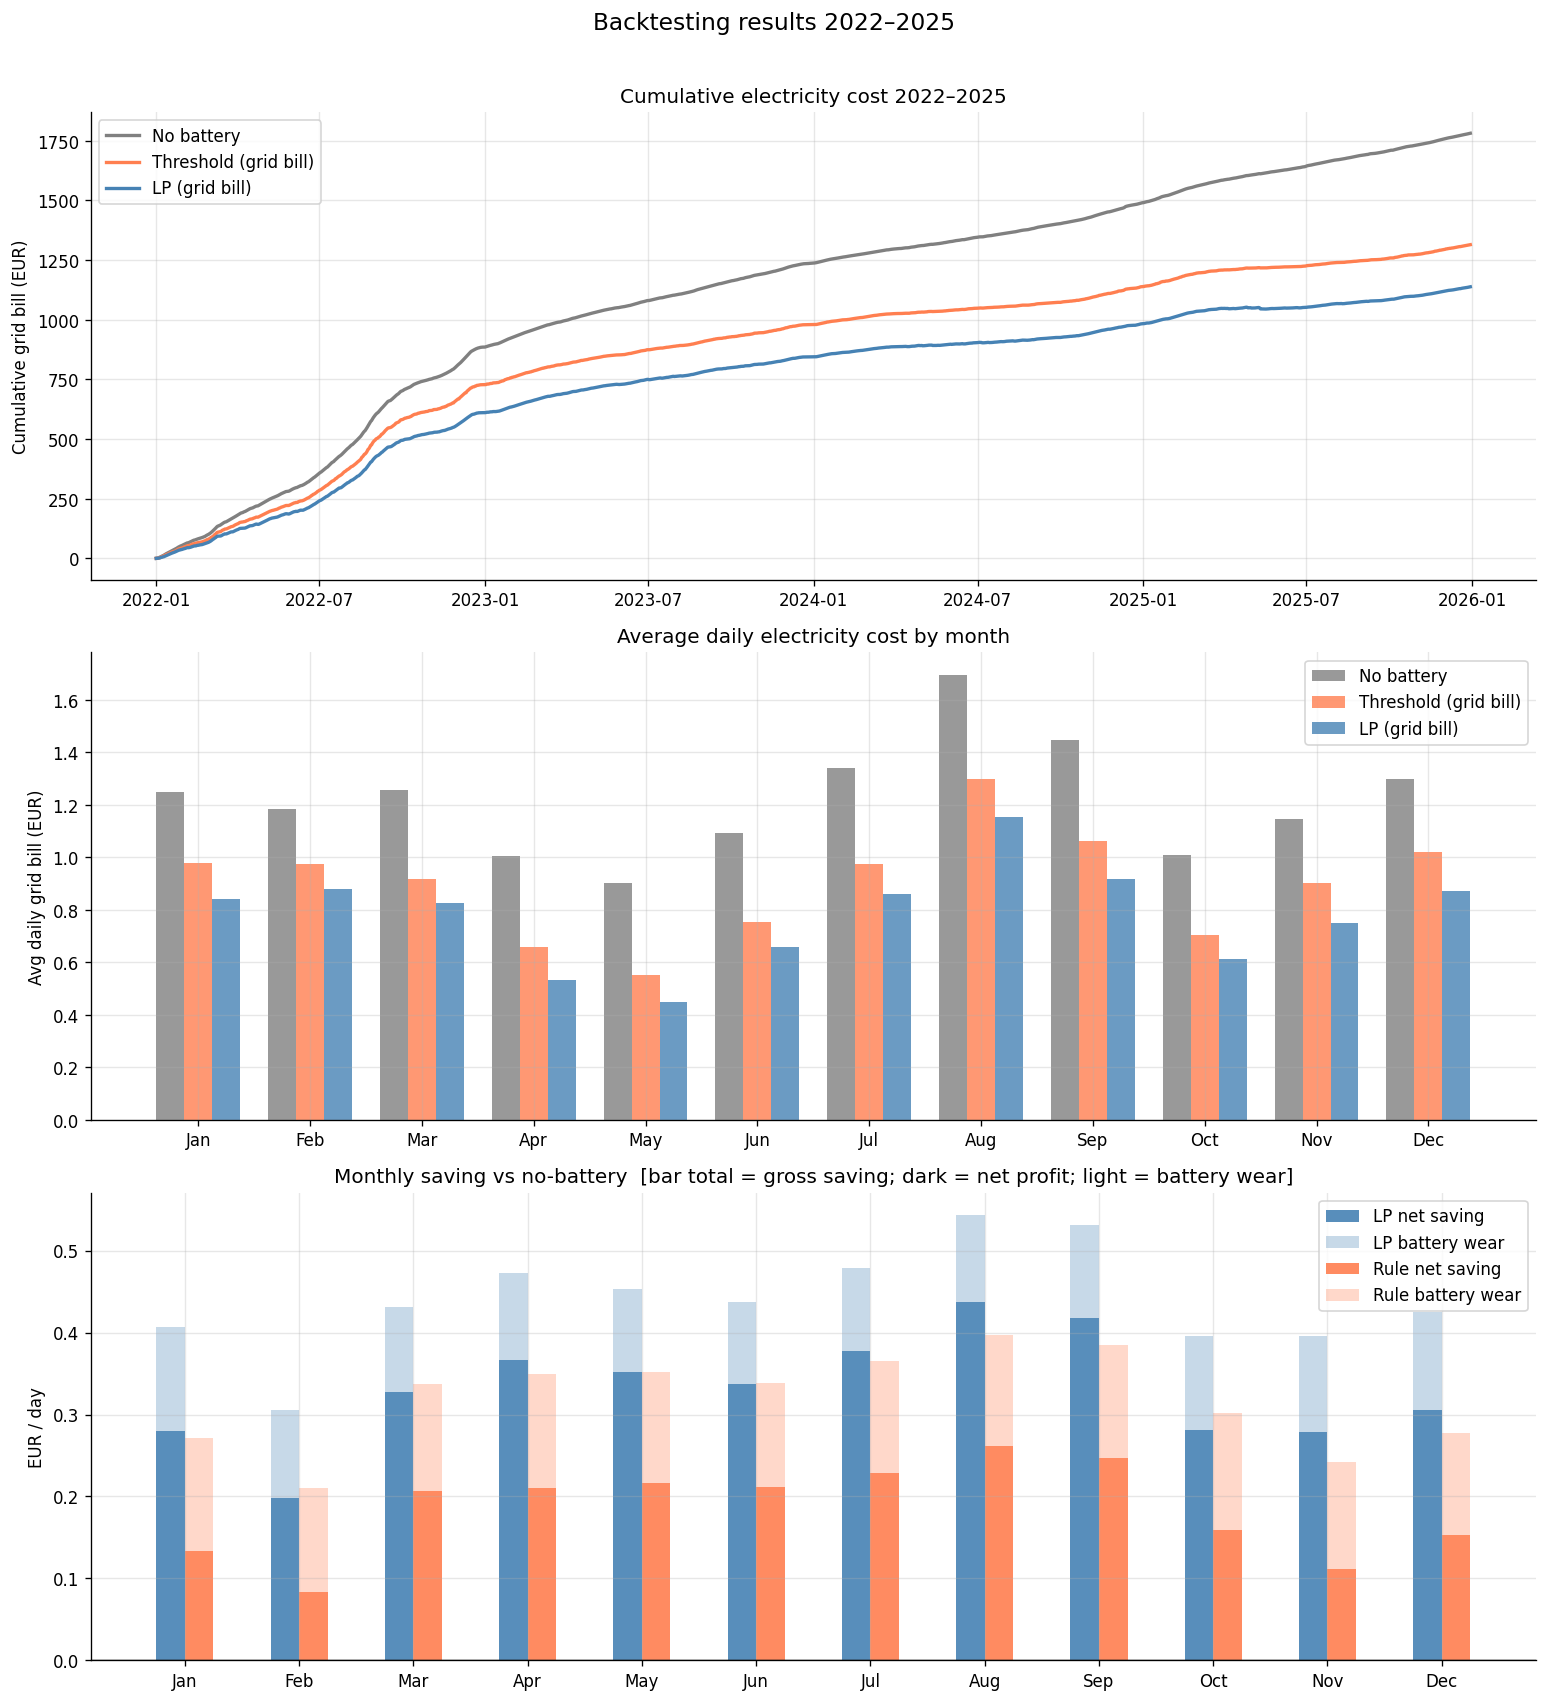

In [8]:
MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(3, 1, figsize=(13, 14))

# ── Cumulative grid bill (electricity only, no degradation) ───────────────────
ax = axes[0]
ax.plot(pd.to_datetime(bt_lp.index),   bt_lp['cost_baseline'].cumsum(),     color='gray',      lw=2, label='No battery')
ax.plot(pd.to_datetime(bt_rule.index), bt_rule['cost_electricity'].cumsum(), color='coral',     lw=2, label='Threshold (grid bill)')
ax.plot(pd.to_datetime(bt_lp.index),   bt_lp['cost_electricity'].cumsum(),   color='steelblue', lw=2, label='LP (grid bill)')
ax.set_ylabel('Cumulative grid bill (EUR)')
ax.set_title('Cumulative electricity cost 2022–2025')
ax.legend()

# ── Average daily grid bill by month ──────────────────────────────────────────
ax2 = axes[1]
base_mo      = bt_lp.groupby('month')['cost_baseline'].mean()
lp_elec_mo   = bt_lp.groupby('month')['cost_electricity'].mean()
rule_elec_mo = bt_rule.groupby('month')['cost_electricity'].mean()
x = np.arange(1, 13)
w = 0.25
ax2.bar(x - w, base_mo.values,      width=w, color='gray',      alpha=0.8, label='No battery')
ax2.bar(x,     rule_elec_mo.values, width=w, color='coral',     alpha=0.8, label='Threshold (grid bill)')
ax2.bar(x + w, lp_elec_mo.values,   width=w, color='steelblue', alpha=0.8, label='LP (grid bill)')
ax2.set_xticks(x)
ax2.set_xticklabels(MONTH_NAMES)
ax2.set_ylabel('Avg daily grid bill (EUR)')
ax2.set_title('Average daily electricity cost by month')
ax2.legend()

# ── Net saving by month: stacked bar (net saving + degradation = gross saving) ─
# Bottom layer = saving_net (real profit after battery wear)
# Top layer    = cost_degradation (battery wear that "eats" into gross saving)
# Total height = saving_electricity (how much less we paid the grid vs no battery)
ax3 = axes[2]
lp_net_mo   = bt_lp.groupby('month')['saving_net'].mean()
rule_net_mo = bt_rule.groupby('month')['saving_net'].mean()
lp_deg_mo   = bt_lp.groupby('month')['cost_degradation'].mean()
rule_deg_mo = bt_rule.groupby('month')['cost_degradation'].mean()

ax3.bar(x - w/2, lp_net_mo.values,   width=w, color='steelblue', alpha=0.9, label='LP net saving')
ax3.bar(x - w/2, lp_deg_mo.values,   width=w, color='steelblue', alpha=0.3,
        bottom=lp_net_mo.values, label='LP battery wear')
ax3.bar(x + w/2, rule_net_mo.values, width=w, color='coral',     alpha=0.9, label='Rule net saving')
ax3.bar(x + w/2, rule_deg_mo.values, width=w, color='coral',     alpha=0.3,
        bottom=rule_net_mo.values, label='Rule battery wear')
ax3.axhline(0, color='black', lw=0.8)
ax3.set_xticks(x)
ax3.set_xticklabels(MONTH_NAMES)
ax3.set_ylabel('EUR / day')
ax3.set_title('Monthly saving vs no-battery  [bar total = gross saving; dark = net profit; light = battery wear]')
ax3.legend()

plt.suptitle('Backtesting results 2022–2025', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5b. Multi-day optimizer behavior — 4 consecutive days

Run LP day-by-day (same as the backtest), carry SOC forward between days, and plot
the full 96-hour schedule to see how the optimizer behaves across day boundaries.

In [26]:
# ── Find the best 4-day window for demonstration ──────────────────────────────
# Two criteria:
#   1. Highest average daily price spread (max-min) → battery earns the most
#   2. Most hours with negative prices → proxy for sunny days (solar overproduction)

N_WINDOW = 4   # window length in days

prices_naive_s = prices.copy()
prices_naive_s.index = prices_naive_s.index.tz_localize(None)

# Daily stats
p_daily = (prices_naive_s['price_eur_kwh']
           .groupby(prices_naive_s.index.date)
           .agg(p_min='min', p_max='max', p_mean='mean',
                neg_hours=lambda x: (x < 0).sum()))
p_daily['spread'] = p_daily['p_max'] - p_daily['p_min']
p_daily.index = pd.to_datetime(p_daily.index)
p_daily = p_daily.sort_index()

# Sliding window over N_WINDOW consecutive days
dates = p_daily.index.tolist()
rows = []
for i in range(len(dates) - N_WINDOW + 1):
    window = p_daily.iloc[i : i + N_WINDOW]
    # Only include windows where all N days are truly consecutive
    delta = (dates[i + N_WINDOW - 1] - dates[i]).days
    if delta != N_WINDOW - 1:
        continue
    rows.append({
        'start':       dates[i].date(),
        'avg_spread':  window['spread'].mean(),
        'total_neg_h': window['neg_hours'].sum(),
        'avg_p_mean':  window['p_mean'].mean(),
    })

windows = pd.DataFrame(rows).set_index('start')

print("── Top 5 windows by price spread (large arbitrage opportunity) ──────────")
print(windows.nlargest(5, 'avg_spread')[['avg_spread', 'total_neg_h', 'avg_p_mean']].round(3))

print("\n── Top 5 windows by negative-price hours (proxy: sunny days) ────────────")
print(windows.nlargest(5, 'total_neg_h')[['total_neg_h', 'avg_spread', 'avg_p_mean']].round(3))

print("\n── Top 5 balanced windows (high spread AND negative hours) ──────────────")
# Normalise both metrics and add them
w = windows.copy()
w['score'] = (w['avg_spread']  - w['avg_spread'].min())  / w['avg_spread'].std() + \
             (w['total_neg_h'] - w['total_neg_h'].min()) / (w['total_neg_h'].std() + 1e-9)
print(w.nlargest(5, 'score')[['avg_spread', 'total_neg_h', 'avg_p_mean']].round(3))

── Top 5 windows by price spread (large arbitrage opportunity) ──────────
            avg_spread  total_neg_h  avg_p_mean
start                                          
2022-08-28       0.413            0       0.544
2022-08-27       0.408            0       0.565
2022-08-26       0.386            0       0.585
2022-08-25       0.377            0       0.574
2022-03-08       0.366            3       0.361

── Top 5 windows by negative-price hours (proxy: sunny days) ────────────
            total_neg_h  avg_spread  avg_p_mean
start                                          
2023-12-23           34       0.048       0.014
2024-08-22           34       0.138       0.031
2023-12-24           33       0.055       0.023
2024-07-04           32       0.143       0.010
2024-08-21           30       0.139       0.037

── Top 5 balanced windows (high spread AND negative hours) ──────────────
            avg_spread  total_neg_h  avg_p_mean
start                                          
2025-05-

Window: 2024-01-15  +4 days  →  96 hours total

Backtest vs 96-hour forecast — per-day comparison:
            cost_baseline  saving_backtest  s_final_backtest  saving_forecast  \
date                                                                            
2024-01-15          0.853            0.436               1.0           -0.057   
2024-01-16          0.968            0.091               1.0            0.657   
2024-01-17          0.881            0.079               1.0            0.079   
2024-01-18          0.826            0.035               1.0            0.035   

            s_final_forecast  
date                          
2024-01-15              6.59  
2024-01-16              1.00  
2024-01-17              1.00  
2024-01-18              1.00  

Total saving — backtest:  0.641 EUR
Total saving — forecast:  0.714 EUR
Extra value of forecast:  +0.072 EUR


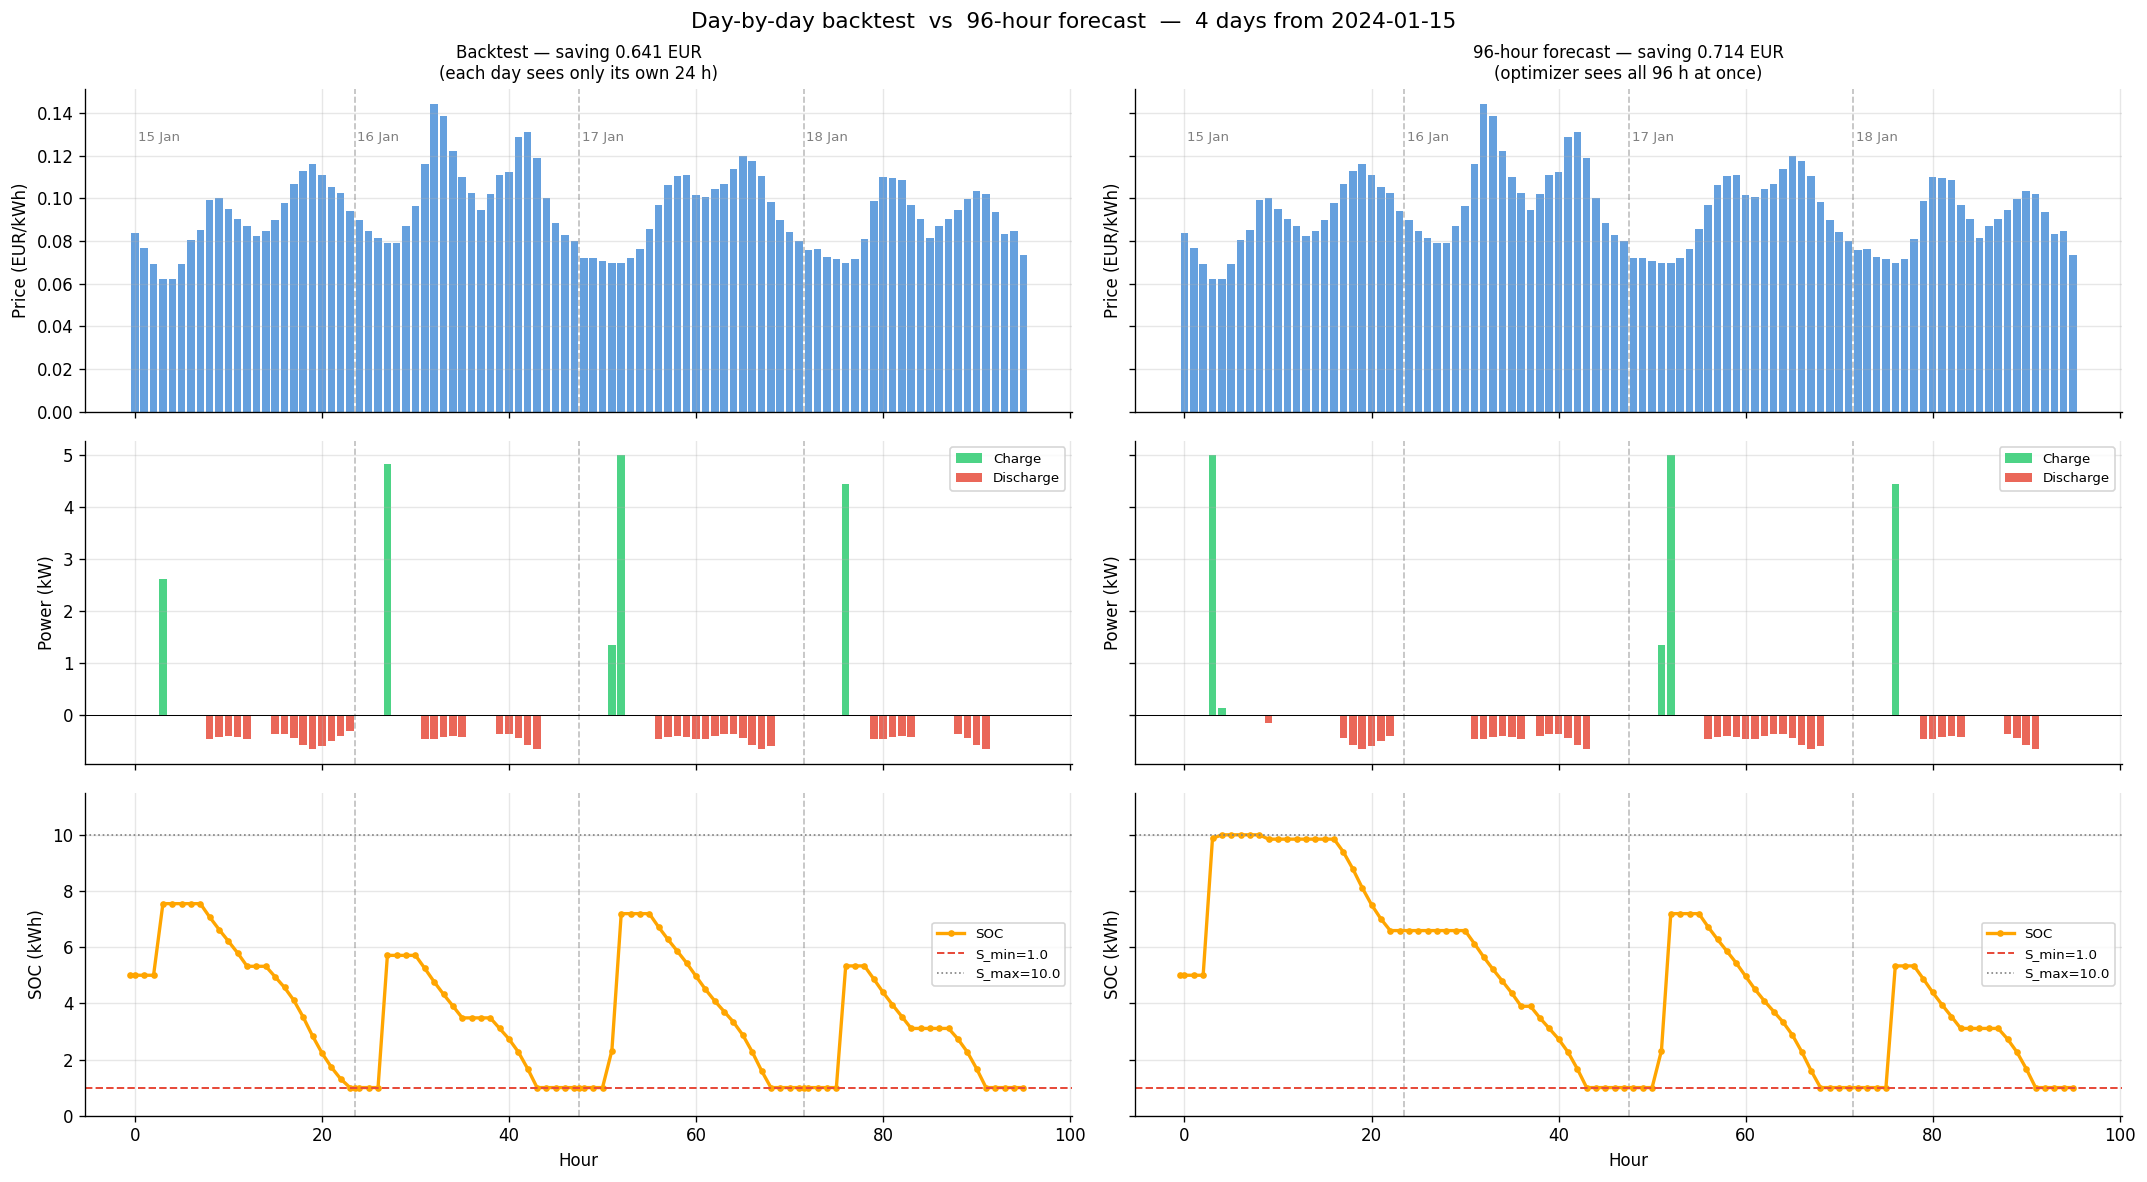

In [32]:
# ── Select 4 consecutive days ─────────────────────────────────────────────────
START_DATE = '2024-01-15'   # change to any date in the dataset
N_DAYS     = 4

start_ts = pd.Timestamp(START_DATE).tz_localize('Europe/Brussels')
end_ts   = start_ts + pd.Timedelta(days=N_DAYS)

prices_4d = prices[(prices.index >= start_ts) & (prices.index < end_ts)]
load_4d   = load[
    (load.index >= pd.Timestamp(START_DATE)) &
    (load.index <  pd.Timestamp(START_DATE) + pd.Timedelta(days=N_DAYS))
]

prices_4d_naive = prices_4d.copy()
prices_4d_naive.index = prices_4d_naive.index.tz_localize(None)

p_all = prices_4d_naive['price_eur_kwh'].values
l_all = load_4d['consumption'].values

T = len(p_all)
if len(l_all) > T:
    l_all = l_all[:T]
elif len(l_all) < T:
    l_all = np.append(l_all, np.repeat(l_all[-1], T - len(l_all)))

print(f"Window: {START_DATE}  +{N_DAYS} days  →  {T} hours total")

# ── Strategy A: backtest (day by day, no knowledge of tomorrow) ───────────────
bt_4d = backtest(prices_4d, load_4d, S_MAX, P_MAX, ETA_C, ETA_D, S_INIT,
                 strategy='lp', binary=False, deg_cost=DEG, S_min=S_MIN)

c_bt, d_bt, s_bt = [], [], []
s = S_INIT
for date in bt_4d.index:
    p = prices_4d_naive[prices_4d_naive.index.date == date]['price_eur_kwh'].values
    l = load_4d[load_4d.index.date == date]['consumption'].values
    res = optimize_day(p, l, S_MAX, P_MAX, ETA_C, ETA_D, s,
                       cyclic=False, binary=False, deg_cost=DEG, S_min=S_MIN)
    c_bt.extend(res['c'])
    d_bt.extend(res['d'])
    s_bt.append(s)
    s_bt.extend(res['s'])
    s = res['s_final']

# ── Strategy B: one LP over all 4 days (perfect forecast) ────────────────────
res_fc = optimize_day(p_all, l_all, S_MAX, P_MAX, ETA_C, ETA_D, S_INIT,
                      cyclic=False, binary=False, deg_cost=DEG, S_min=S_MIN)

cost_base = float(np.dot(p_all, l_all))
saving_bt = cost_base - bt_4d['cost'].sum()
saving_fc = cost_base - res_fc['cost']

# ── Per-day saving and s_final for the 96-hour forecast ──────────────────────
s_fc_eod, saving_fc_day = [], []
for i in range(N_DAYS):
    h = slice(i * 24, (i + 1) * 24)
    cost_elec = float(np.dot(p_all[h], l_all[h] + np.array(res_fc['c'][h]) - np.array(res_fc['d'][h])))
    cost_deg  = DEG * sum(res_fc['c'][h])
    saving_fc_day.append(bt_4d['cost_baseline'].iloc[i] - cost_elec - cost_deg)
    s_fc_eod.append(float(res_fc['s'][(i + 1) * 24 - 1]))

# ── Comparison table ──────────────────────────────────────────────────────────
comparison = bt_4d[['cost_baseline', 'saving_net', 's_final']].copy()
comparison.columns = ['cost_baseline', 'saving_backtest', 's_final_backtest']
comparison['saving_forecast'] = saving_fc_day
comparison['s_final_forecast'] = s_fc_eod

print("\nBacktest vs 96-hour forecast — per-day comparison:")
print(comparison.round(3))
print(f"\nTotal saving — backtest:  {saving_bt:.3f} EUR")
print(f"Total saving — forecast:  {saving_fc:.3f} EUR")
print(f"Extra value of forecast:  {saving_fc - saving_bt:+.3f} EUR")

# ── Plot ──────────────────────────────────────────────────────────────────────
s_fc_plot = [S_INIT] + [float(v) for v in res_fc['s']]

x_hours = list(range(T))
x_soc_bt = []
for i in range(N_DAYS):
    x_soc_bt.extend([i * 24 - 0.5] + list(range(i * 24, i * 24 + 24)))
x_soc_fc = [-0.5] + x_hours

fig, axes = plt.subplots(3, 2, figsize=(18, 10), sharex='col', sharey='row')
fig.suptitle(
    f'Day-by-day backtest  vs  96-hour forecast  —  {N_DAYS} days from {START_DATE}',
    fontsize=13
)

bar_colors = ['#e74c3c' if p < 0 else '#4a90d9' for p in p_all]

for col, (title, c_v, d_v, s_v, x_s) in enumerate([
    (f'Backtest — saving {saving_bt:.3f} EUR\n(each day sees only its own 24 h)',
     c_bt, d_bt, s_bt, x_soc_bt),
    (f'96-hour forecast — saving {saving_fc:.3f} EUR\n(optimizer sees all {T} h at once)',
     res_fc['c'], res_fc['d'], s_fc_plot, x_soc_fc),
]):
    for i in range(1, N_DAYS):
        bnd = i * 24 - 0.5
        for row in range(3):
            axes[row, col].axvline(bnd, color='gray', lw=1, ls='--', alpha=0.5)
        axes[0, col].text(bnd + 0.3, max(p_all) * 0.88,
                          (pd.Timestamp(START_DATE) + pd.Timedelta(days=i)).strftime('%d %b'),
                          fontsize=8, color='gray')
    axes[0, col].text(0.3, max(p_all) * 0.88,
                      pd.Timestamp(START_DATE).strftime('%d %b'), fontsize=8, color='gray')

    axes[0, col].bar(x_hours, p_all, color=bar_colors, alpha=0.85)
    axes[0, col].set_title(title, fontsize=10)
    axes[0, col].set_ylabel('Price (EUR/kWh)')

    axes[1, col].bar(x_hours, c_v, color='#2ecc71', alpha=0.85, label='Charge')
    axes[1, col].bar(x_hours, [-d for d in d_v], color='#e74c3c', alpha=0.85, label='Discharge')
    axes[1, col].axhline(0, color='black', lw=0.6)
    axes[1, col].set_ylabel('Power (kW)')
    axes[1, col].legend(fontsize=8)

    axes[2, col].plot(x_s, s_v, color='orange', lw=2, marker='o', ms=3, label='SOC')
    axes[2, col].axhline(S_MIN, color='#e74c3c', lw=1.2, ls='--', label=f'S_min={S_MIN}')
    axes[2, col].axhline(S_MAX, color='gray',    lw=1,   ls=':',  label=f'S_max={S_MAX}')
    axes[2, col].set_ylim(0, S_MAX * 1.15)
    axes[2, col].set_ylabel('SOC (kWh)')
    axes[2, col].set_xlabel('Hour')
    axes[2, col].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6. Sensitivity analysis

How do net savings change when we vary one battery parameter at a time?

- **S_max** — capacity (kWh): does a bigger battery always pay off?
- **S_min** — minimum SOC (%): how much does depth-of-discharge protection cost?
- **P_max** — power (kW): is there a point where more power stops helping?
- **S_max × P_max** — 2D table: these two interact (big battery + small power = bottleneck)

All runs use the **threshold strategy** (fast). Baseline values are marked with ★.

Results loaded from files.


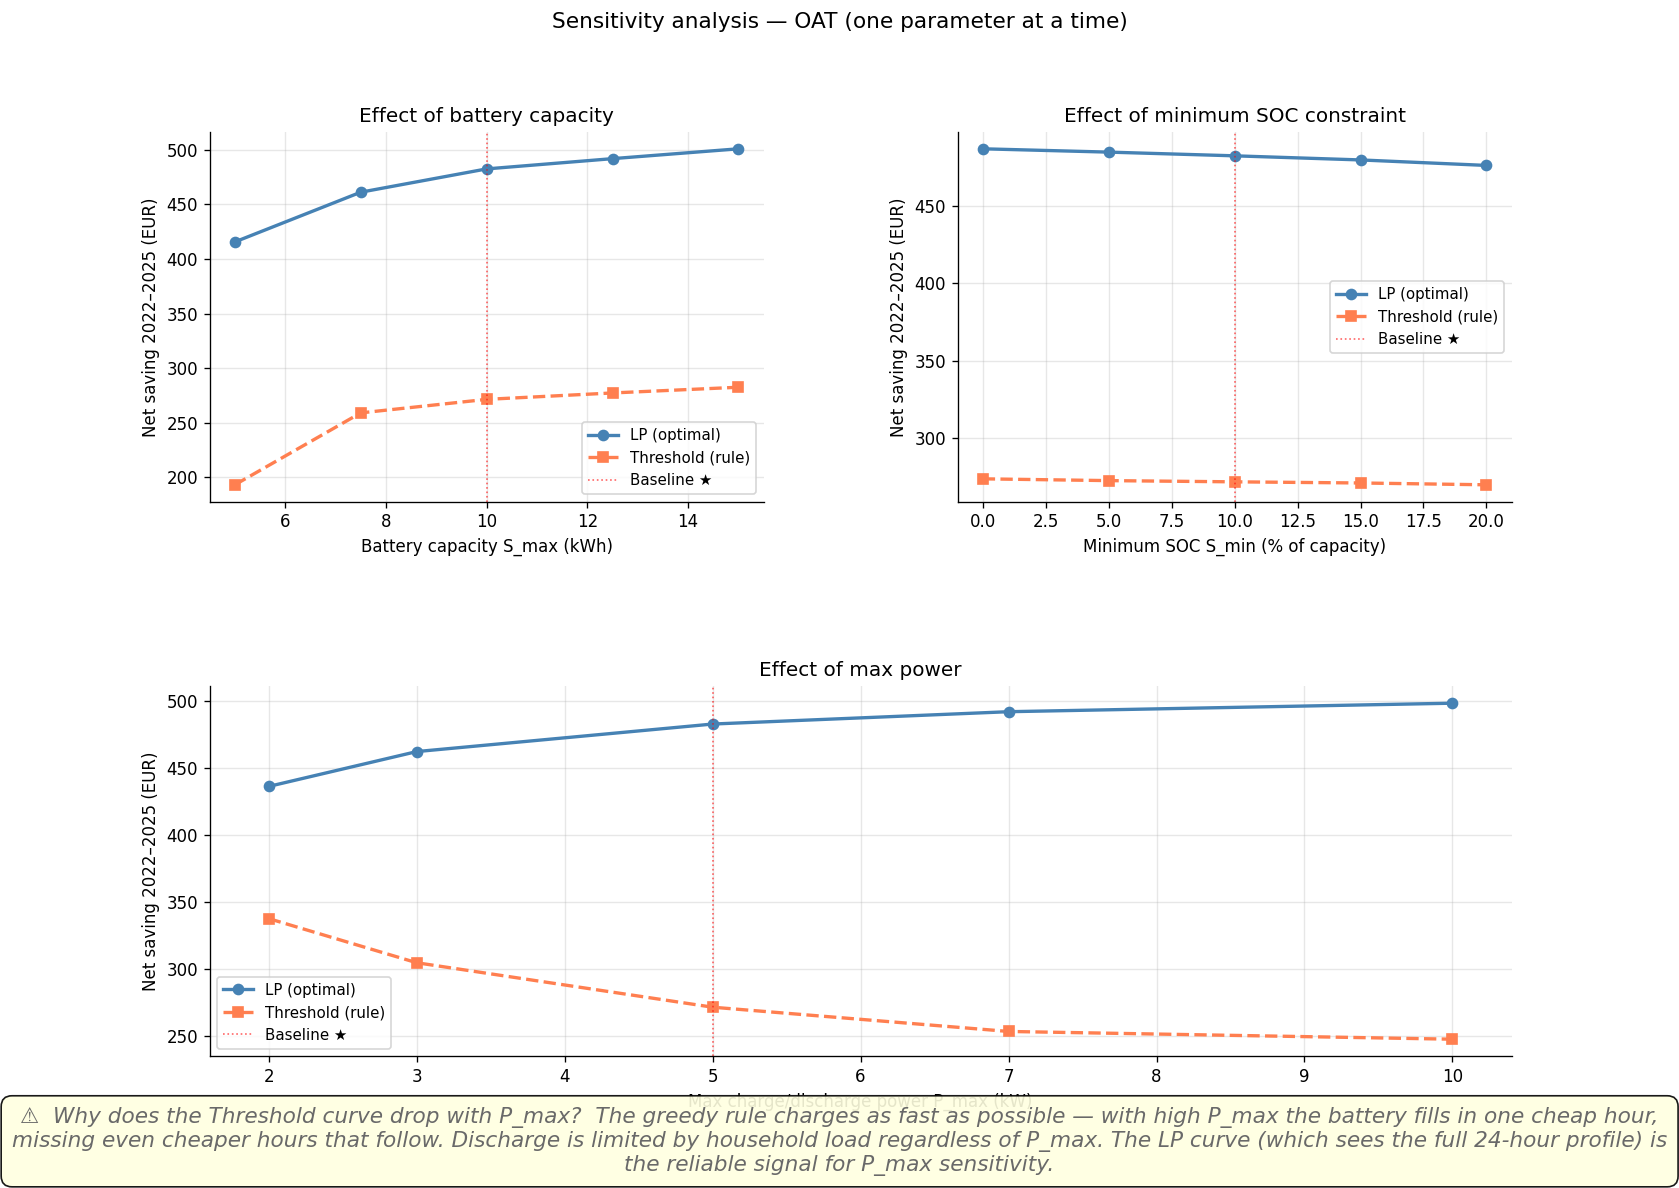

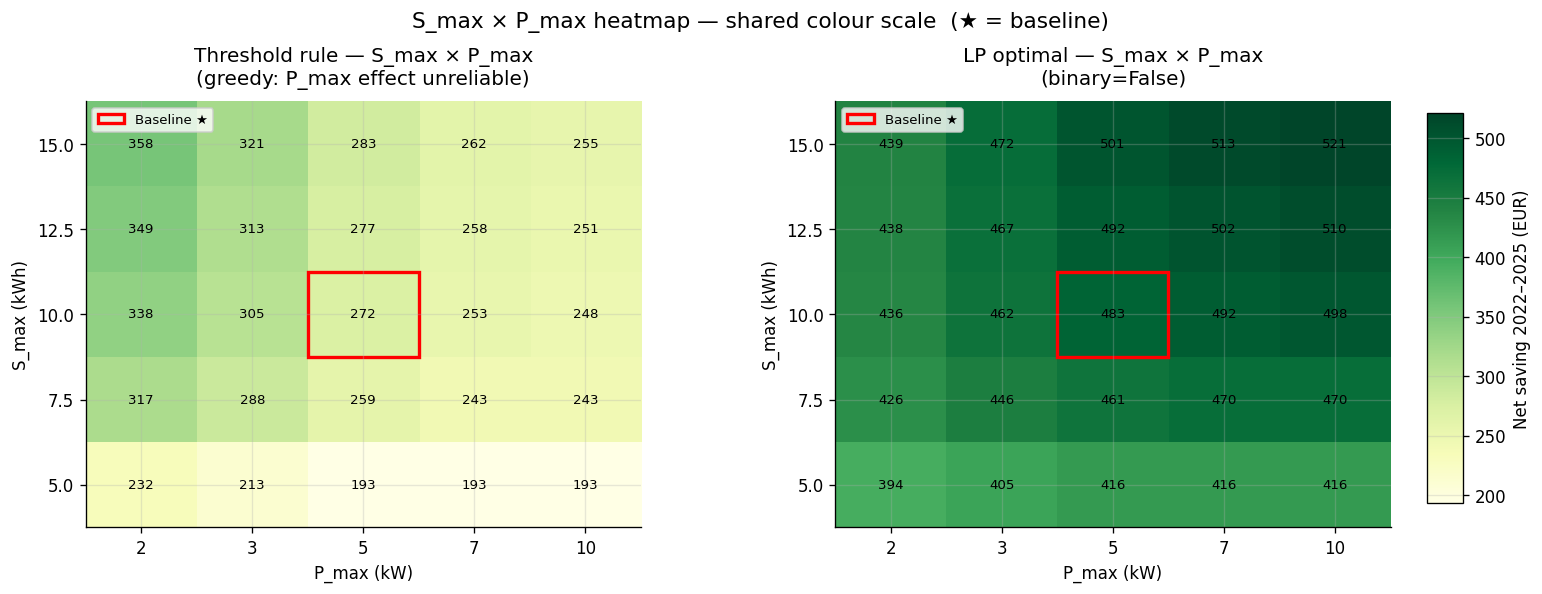

In [17]:
import time
from pathlib import Path
import matplotlib.gridspec as gridspec

RECOMPUTE  = False   # False → load saved results, True → rerun (slow)
SENS_DIR   = Path('../results/sensitivity')
SENS_DIR.mkdir(parents=True, exist_ok=True)

# ── Parameter ranges ───────────────────────────────────────────────────────────
s_max_vals = [5.0, 7.5, 10.0, 12.5, 15.0]
s_min_pcts = [0, 5, 10, 15, 20]
p_max_vals = [2.0, 3.0, 5.0, 7.0, 10.0]

if RECOMPUTE:
    t0 = time.time()

    # ── OAT: S_max ────────────────────────────────────────────────────────────
    lp_smax, rule_smax = [], []
    for s_max in s_max_vals:
        kw = dict(S_init=0.5*s_max, deg_cost=DEG, S_min=0.1*s_max)
        lp_smax.append(
            backtest(prices, load, s_max, P_MAX, ETA_C, ETA_D,
                     strategy='lp', binary=False, **kw)['saving_net'].sum())
        rule_smax.append(
            backtest(prices, load, s_max, P_MAX, ETA_C, ETA_D,
                     strategy='threshold', **kw)['saving_net'].sum())
    print(f"S_max OAT done  ({time.time()-t0:.1f}s)")

    # ── OAT: S_min ────────────────────────────────────────────────────────────
    lp_smin, rule_smin = [], []
    for pct in s_min_pcts:
        kw = dict(S_init=S_INIT, deg_cost=DEG, S_min=pct/100*S_MAX)
        lp_smin.append(
            backtest(prices, load, S_MAX, P_MAX, ETA_C, ETA_D,
                     strategy='lp', binary=False, **kw)['saving_net'].sum())
        rule_smin.append(
            backtest(prices, load, S_MAX, P_MAX, ETA_C, ETA_D,
                     strategy='threshold', **kw)['saving_net'].sum())
    print(f"S_min OAT done  ({time.time()-t0:.1f}s)")

    # ── OAT: P_max ────────────────────────────────────────────────────────────
    lp_pmax, rule_pmax = [], []
    for p_max in p_max_vals:
        kw = dict(S_init=S_INIT, deg_cost=DEG, S_min=S_MIN)
        lp_pmax.append(
            backtest(prices, load, S_MAX, p_max, ETA_C, ETA_D,
                     strategy='lp', binary=False, **kw)['saving_net'].sum())
        rule_pmax.append(
            backtest(prices, load, S_MAX, p_max, ETA_C, ETA_D,
                     strategy='threshold', **kw)['saving_net'].sum())
    print(f"P_max OAT done  ({time.time()-t0:.1f}s)")

    # ── 2D grid: S_max × P_max — threshold (fast) ─────────────────────────────
    grid_rule = np.zeros((len(s_max_vals), len(p_max_vals)))
    for i, s_max in enumerate(s_max_vals):
        for j, p_max in enumerate(p_max_vals):
            bt_g = backtest(prices, load, s_max, p_max, ETA_C, ETA_D,
                            S_init=0.5*s_max, strategy='threshold',
                            deg_cost=DEG, S_min=0.1*s_max)
            grid_rule[i, j] = bt_g['saving_net'].sum()
    print(f"Grid threshold done  ({time.time()-t0:.1f}s)")

    # ── 2D grid: S_max × P_max — LP (binary=False for speed) ──────────────────
    grid_lp = np.zeros((len(s_max_vals), len(p_max_vals)))
    for i, s_max in enumerate(s_max_vals):
        for j, p_max in enumerate(p_max_vals):
            bt_g = backtest(prices, load, s_max, p_max, ETA_C, ETA_D,
                            S_init=0.5*s_max, strategy='lp', binary=False,
                            deg_cost=DEG, S_min=0.1*s_max)
            grid_lp[i, j] = bt_g['saving_net'].sum()
    print(f"Grid LP done   ({time.time()-t0:.1f}s)")

    # ── Save results ──────────────────────────────────────────────────────────
    pd.DataFrame({'s_max': s_max_vals, 'lp': lp_smax, 'threshold': rule_smax}
                 ).to_csv(SENS_DIR / 'oat_smax.csv', index=False)
    pd.DataFrame({'s_min_pct': s_min_pcts, 'lp': lp_smin, 'threshold': rule_smin}
                 ).to_csv(SENS_DIR / 'oat_smin.csv', index=False)
    pd.DataFrame({'p_max': p_max_vals, 'lp': lp_pmax, 'threshold': rule_pmax}
                 ).to_csv(SENS_DIR / 'oat_pmax.csv', index=False)
    pd.DataFrame(grid_rule, index=s_max_vals, columns=p_max_vals
                 ).to_csv(SENS_DIR / 'grid_smax_pmax_threshold.csv')
    pd.DataFrame(grid_lp, index=s_max_vals, columns=p_max_vals
                 ).to_csv(SENS_DIR / 'grid_smax_pmax_lp.csv')
    print(f"Saved to {SENS_DIR.resolve()}")

else:
    # ── Load saved results ────────────────────────────────────────────────────
    df_smax = pd.read_csv(SENS_DIR / 'oat_smax.csv')
    df_smin = pd.read_csv(SENS_DIR / 'oat_smin.csv')
    df_pmax = pd.read_csv(SENS_DIR / 'oat_pmax.csv')
    df_grid_rule = pd.read_csv(SENS_DIR / 'grid_smax_pmax_threshold.csv', index_col=0)
    df_grid_lp   = pd.read_csv(SENS_DIR / 'grid_smax_pmax_lp.csv',       index_col=0)

    s_max_vals = df_smax['s_max'].tolist()
    lp_smax,  rule_smax  = df_smax['lp'].tolist(),  df_smax['threshold'].tolist()
    s_min_pcts = df_smin['s_min_pct'].tolist()
    lp_smin,  rule_smin  = df_smin['lp'].tolist(),  df_smin['threshold'].tolist()
    p_max_vals = df_pmax['p_max'].tolist()
    lp_pmax,  rule_pmax  = df_pmax['lp'].tolist(),  df_pmax['threshold'].tolist()
    grid_rule  = df_grid_rule.values
    grid_lp    = df_grid_lp.values
    print("Results loaded from files.")

# ── OAT plots: S_max + S_min on top, P_max full-width on bottom ───────────────
def oat_plot(ax, xs, lp_vals, rule_vals, baseline_x, xlabel, title):
    ax.plot(xs, lp_vals,   marker='o', color='steelblue', lw=2, label='LP (optimal)')
    ax.plot(xs, rule_vals, marker='s', color='coral',     lw=2, ls='--', label='Threshold (rule)')
    ax.axvline(baseline_x, color='red', lw=1, ls=':', alpha=0.6, label='Baseline ★')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Net saving 2022–2025 (EUR)')
    ax.set_title(title)
    ax.legend(fontsize=9)

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.5, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])  # P_max takes full bottom row

oat_plot(ax1, s_max_vals, lp_smax, rule_smax, S_MAX,
         'Battery capacity S_max (kWh)', 'Effect of battery capacity')
oat_plot(ax2, s_min_pcts, lp_smin, rule_smin, S_MIN/S_MAX*100,
         'Minimum SOC S_min (% of capacity)', 'Effect of minimum SOC constraint')
oat_plot(ax3, p_max_vals, lp_pmax, rule_pmax, P_MAX,
         'Max charge/discharge power P_max (kW)', 'Effect of max power')

# Explanation note below the P_max plot — larger font
fig.text(
    0.5, 0.01,
    '⚠  Why does the Threshold curve drop with P_max?  '
    'The greedy rule charges as fast as possible — with high P_max the battery fills in one cheap hour, '
    'missing even cheaper hours that follow. Discharge is limited by household load regardless of P_max. '
    'The LP curve (which sees the full 24-hour profile) is the reliable signal for P_max sensitivity.',
    ha='center', va='bottom', fontsize=13, color='dimgray', style='italic',
    wrap=True,
    bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.9)
)

plt.suptitle('Sensitivity analysis — OAT (one parameter at a time)', fontsize=13)
plt.tight_layout(rect=[0, 0.10, 1, 0.95])  # space at bottom for note, at top for suptitle
plt.show()

# ── Heatmaps: Threshold vs LP, shared colour scale, colorbar outside ──────────
vmin = min(grid_rule.min(), grid_lp.min())
vmax = max(grid_rule.max(), grid_lp.max())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# top=0.82 leaves room between subplot titles and suptitle
fig.subplots_adjust(right=0.85, wspace=0.35, top=0.82)

def heatmap_plot(ax, grid, title):
    im = ax.imshow(grid, aspect='auto', cmap='YlGn', origin='lower', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(p_max_vals)))
    ax.set_xticklabels([f'{v:.0f}' for v in p_max_vals])
    ax.set_yticks(range(len(s_max_vals)))
    ax.set_yticklabels([f'{v:.1f}' for v in s_max_vals])
    ax.set_xlabel('P_max (kW)')
    ax.set_ylabel('S_max (kWh)')
    ax.set_title(title, pad=10)
    bi, bj = s_max_vals.index(S_MAX), p_max_vals.index(P_MAX)
    ax.add_patch(plt.Rectangle((bj-0.5, bi-0.5), 1, 1,
                 fill=False, edgecolor='red', lw=2, label='Baseline ★'))
    ax.legend(loc='upper left', fontsize=8)
    for i in range(len(s_max_vals)):
        for j in range(len(p_max_vals)):
            ax.text(j, i, f'{grid[i,j]:.0f}', ha='center', va='center', fontsize=8)
    return im

heatmap_plot(axes[0], grid_rule,
             'Threshold rule — S_max × P_max\n(greedy: P_max effect unreliable)')
im = heatmap_plot(axes[1], grid_lp,
                  'LP optimal — S_max × P_max\n(binary=False)')

# Single colorbar in its own axis, fully outside the heatmaps
cbar_ax = fig.add_axes([0.87, 0.15, 0.02, 0.65])
fig.colorbar(im, cax=cbar_ax, label='Net saving 2022–2025 (EUR)')

plt.suptitle('S_max × P_max heatmap — shared colour scale  (★ = baseline)',
             fontsize=13, y=0.97)
plt.show()

## 7. Payback analysis

How many years until the battery pays for itself?

**Assumptions for the 10-year projection:**
- Base annual saving = average over the 4-year backtest (2022–2025)
- `saving_net` already includes per-cycle degradation cost (`deg_cost`) — no double-counting
- **Capacity degradation** (~2.5%/yr LFP): battery gradually stores less → proportionally lower savings
- **Electricity price growth** (~3%/yr): higher future prices → proportionally higher savings
- Both effects are applied as multipliers on the base saving each year

Price scale factor: ×1.21  (VAT 21%)
Average annual net saving — LP:            146 EUR/year  (incl. VAT)
Average annual net saving — Threshold:      82 EUR/year  (incl. VAT)
Simple payback — LP:        27.4 years
Simple payback — Threshold: 48.7 years

10-year projection  [inflation 3%/yr | capacity loss 2.5%/yr | VAT 21%]
      LP saving (EUR)  LP cumulative (EUR)  Rule saving (EUR)  Rule cumulative (EUR)
year                                                                                
1                 147                  147                 82                     82
2                 147                  294                 83                    165
3                 148                  441                 83                    248
4                 148                  589                 83                    332
5                 148                  737                 83                    415
6                 148                  886                 83                  

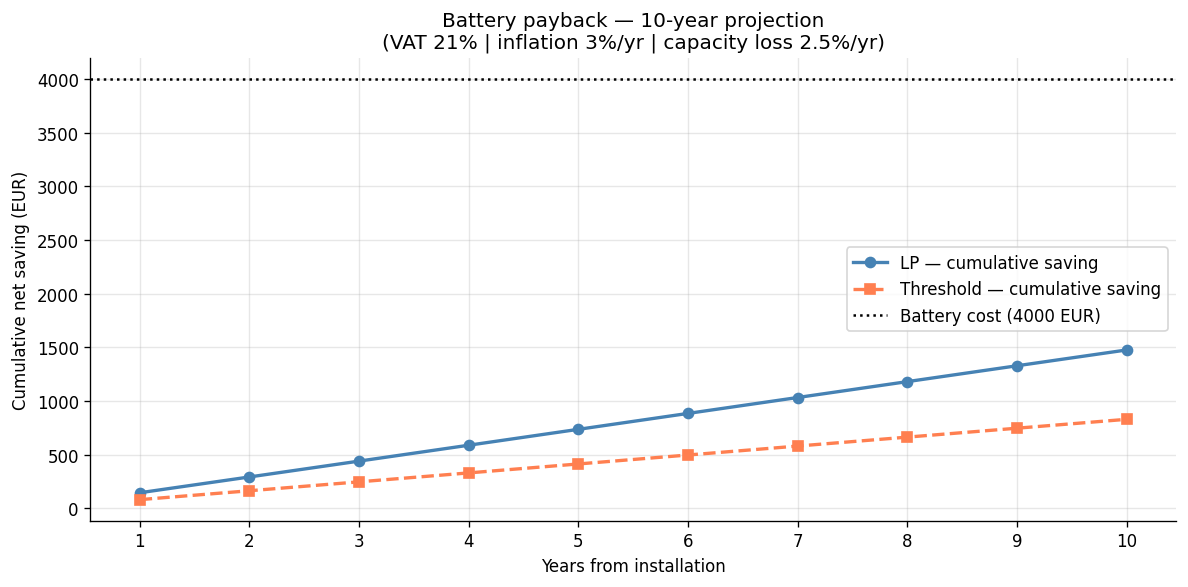

In [9]:
# ── Investment & price parameters ────────────────────────────────────────────
BATTERY_COST         = 4000   # EUR — installed cost (battery + inverter + installation)
PROJECTION_YEARS     = 10     # years to project forward
PRICE_INFLATION      = 0.03   # 3%/yr — electricity price growth (Belgian historical avg)
CAPACITY_DEGRADATION = 0.025  # 2.5%/yr — LFP capacity loss (≈20-25% over 10 years)

# Model uses raw EPEX spot prices. Real consumer price = spot + markup + VAT + levies.
# Fixed markup (DSO grid fee, supplier margin) cancels out in saving_net (paid with and without battery).
# VAT (21%) and price-proportional levies DO scale savings — apply as a multiplier here.
VAT                = 0.21   # Belgian VAT on electricity
PRICE_SCALE_FACTOR = 1 + VAT  # effective saving multiplier (extend if other % levies apply)

# ── Base annual saving from backtest (scaled to effective consumer price) ─────
n_years  = bt_lp['year'].nunique()
avg_lp   = bt_lp['saving_net'].sum()   / n_years * PRICE_SCALE_FACTOR
avg_rule = bt_rule['saving_net'].sum() / n_years * PRICE_SCALE_FACTOR

print(f"Price scale factor: ×{PRICE_SCALE_FACTOR:.2f}  (VAT {VAT*100:.0f}%)")
print(f"Average annual net saving — LP:        {avg_lp:7.0f} EUR/year  (incl. VAT)")
print(f"Average annual net saving — Threshold: {avg_rule:7.0f} EUR/year  (incl. VAT)")
print(f"Simple payback — LP:        {BATTERY_COST / avg_lp:.1f} years")
print(f"Simple payback — Threshold: {BATTERY_COST / avg_rule:.1f} years")

# ── Year-by-year projection ───────────────────────────────────────────────────
# saving_year_n = base × capacity_factor × price_factor
# capacity_factor = 1 - CAPACITY_DEGRADATION × n   (linear capacity loss)
# price_factor    = (1 + PRICE_INFLATION) ^ n       (compound price growth)
years       = list(range(1, PROJECTION_YEARS + 1))
lp_annual, rule_annual = [], []

for n in years:
    cap_factor   = max(0, 1 - CAPACITY_DEGRADATION * n)
    price_factor = (1 + PRICE_INFLATION) ** n
    lp_annual.append(avg_lp   * cap_factor * price_factor)
    rule_annual.append(avg_rule * cap_factor * price_factor)

lp_cumul   = [sum(lp_annual[:i+1])   for i in range(PROJECTION_YEARS)]
rule_cumul = [sum(rule_annual[:i+1]) for i in range(PROJECTION_YEARS)]

# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for i, n in enumerate(years):
    rows.append({
        'year':                  n,
        'LP saving (EUR)':       round(lp_annual[i]),
        'LP cumulative (EUR)':   round(lp_cumul[i]),
        'Rule saving (EUR)':     round(rule_annual[i]),
        'Rule cumulative (EUR)': round(rule_cumul[i]),
    })
proj_df = pd.DataFrame(rows).set_index('year')
print(f"\n{PROJECTION_YEARS}-year projection  "
      f"[inflation {PRICE_INFLATION*100:.0f}%/yr | capacity loss {CAPACITY_DEGRADATION*100:.1f}%/yr | VAT {VAT*100:.0f}%]")
print(proj_df.to_string())

# ── Payback year ──────────────────────────────────────────────────────────────
def payback_year(cumul, cost):
    for i, c in enumerate(cumul):
        if c >= cost:
            return i + 1
    return None

pb_lp   = payback_year(lp_cumul,   BATTERY_COST)
pb_rule = payback_year(rule_cumul, BATTERY_COST)

print(f"\nBattery cost: {BATTERY_COST} EUR")
print(f"Payback LP:        {'year ' + str(pb_lp) if pb_lp else 'not reached in ' + str(PROJECTION_YEARS) + ' years'}")
print(f"Payback Threshold: {'year ' + str(pb_rule) if pb_rule else 'not reached in ' + str(PROJECTION_YEARS) + ' years'}")
print(f"10-year net gain LP:        {lp_cumul[-1] - BATTERY_COST:+.0f} EUR")
print(f"10-year net gain Threshold: {rule_cumul[-1] - BATTERY_COST:+.0f} EUR")

# ── Chart ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(years, lp_cumul,   marker='o', color='steelblue', lw=2, label='LP — cumulative saving')
ax.plot(years, rule_cumul, marker='s', color='coral',     lw=2, ls='--', label='Threshold — cumulative saving')
ax.axhline(BATTERY_COST, color='black', lw=1.5, ls=':', label=f'Battery cost ({BATTERY_COST} EUR)')

if pb_lp:
    ax.axvline(pb_lp,   color='steelblue', lw=1, ls='--', alpha=0.5)
if pb_rule:
    ax.axvline(pb_rule, color='coral',     lw=1, ls='--', alpha=0.5)

ax.set_xlabel('Years from installation')
ax.set_ylabel('Cumulative net saving (EUR)')
ax.set_title(f'Battery payback — {PROJECTION_YEARS}-year projection\n'
             f'(VAT {VAT*100:.0f}% | inflation {PRICE_INFLATION*100:.0f}%/yr | '
             f'capacity loss {CAPACITY_DEGRADATION*100:.1f}%/yr)')
ax.set_xticks(years)
ax.legend()
plt.tight_layout()
plt.show()

### 7b. Crisis year vs normal market

2022 was an exceptional year (energy crisis → extreme price volatility → high arbitrage savings).  
This cell separates the **crisis year** from the **normal market** (2023–2025) to show
how much the payback estimate depends on which period you use as a baseline.

Crisis year (2022):       274 EUR/year  (incl. VAT 21%)
Normal years [np.int64(2023), np.int64(2024), np.int64(2025)]:    103 EUR/year  (incl. VAT 21%)
Full period average:            146 EUR/year

Simple payback — crisis year as baseline:  14.6 years
Simple payback — normal market as baseline: 38.7 years
Simple payback — full 4-yr average:         27.4 years


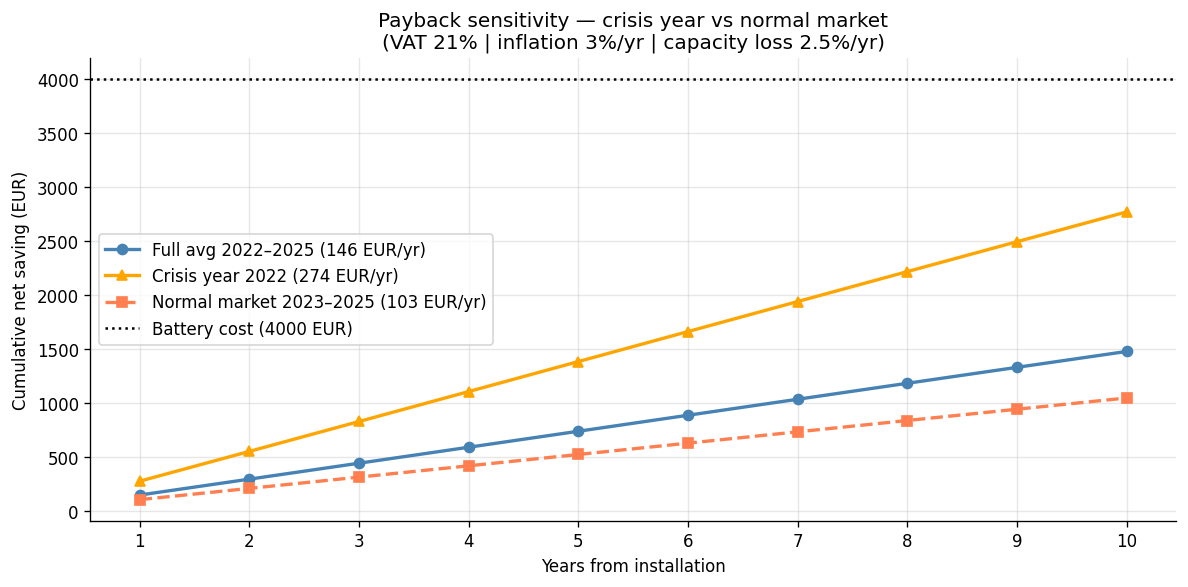

In [11]:
# ── Split backtest into crisis year vs normal market ──────────────────────────
CRISIS_YEAR  = 2022
normal_years = [y for y in bt_lp['year'].unique() if y != CRISIS_YEAR]

bt_crisis = bt_lp[bt_lp['year'] == CRISIS_YEAR]
bt_normal = bt_lp[bt_lp['year'].isin(normal_years)]

# Annual averages for each period (LP strategy, scaled with VAT)
avg_crisis = bt_crisis['saving_net'].sum() * PRICE_SCALE_FACTOR          # only 1 year
avg_normal = bt_normal['saving_net'].sum() / len(normal_years) * PRICE_SCALE_FACTOR

print(f"Crisis year ({CRISIS_YEAR}):    {avg_crisis:6.0f} EUR/year  (incl. VAT {VAT*100:.0f}%)")
print(f"Normal years {normal_years}: {avg_normal:6.0f} EUR/year  (incl. VAT {VAT*100:.0f}%)")
print(f"Full period average:         {avg_lp:6.0f} EUR/year")
print()
print(f"Simple payback — crisis year as baseline:  {BATTERY_COST / avg_crisis:.1f} years")
print(f"Simple payback — normal market as baseline: {BATTERY_COST / avg_normal:.1f} years")
print(f"Simple payback — full 4-yr average:         {BATTERY_COST / avg_lp:.1f} years")

# ── 10-year projection for both scenarios ─────────────────────────────────────
proj_years = list(range(1, PROJECTION_YEARS + 1))
cumul_crisis, cumul_normal = [], []

for n in proj_years:
    cap_factor   = max(0, 1 - CAPACITY_DEGRADATION * n)
    price_factor = (1 + PRICE_INFLATION) ** n
    cumul_crisis.append(sum(avg_crisis * max(0, 1 - CAPACITY_DEGRADATION * k) * (1 + PRICE_INFLATION)**k
                            for k in range(1, n + 1)))
    cumul_normal.append(sum(avg_normal * max(0, 1 - CAPACITY_DEGRADATION * k) * (1 + PRICE_INFLATION)**k
                            for k in range(1, n + 1)))

# ── Chart ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(proj_years, lp_cumul,      marker='o', color='steelblue', lw=2,      label=f'Full avg 2022–2025 ({avg_lp:.0f} EUR/yr)')
ax.plot(proj_years, cumul_crisis,  marker='^', color='orange',    lw=2,      label=f'Crisis year {CRISIS_YEAR} ({avg_crisis:.0f} EUR/yr)')
ax.plot(proj_years, cumul_normal,  marker='s', color='coral',     lw=2, ls='--', label=f'Normal market {normal_years[0]}–{normal_years[-1]} ({avg_normal:.0f} EUR/yr)')
ax.axhline(BATTERY_COST, color='black', lw=1.5, ls=':', label=f'Battery cost ({BATTERY_COST} EUR)')

ax.set_xlabel('Years from installation')
ax.set_ylabel('Cumulative net saving (EUR)')
ax.set_title(f'Payback sensitivity — crisis year vs normal market\n'
             f'(VAT {VAT*100:.0f}% | inflation {PRICE_INFLATION*100:.0f}%/yr | capacity loss {CAPACITY_DEGRADATION*100:.1f}%/yr)')
ax.set_xticks(proj_years)
ax.legend()
plt.tight_layout()
plt.show()

### 7c. Battery lifespan — EFC vs payback period

Manufacturers guarantee LFP batteries for a fixed number of **Equivalent Full Cycles (EFC)**
and a calendar period — whichever limit is reached first.

> **1 EFC** = charging the full battery capacity once (e.g. 10 kWh in a 10 kWh battery).

If our strategy uses few cycles per year, the battery lasts longer cycle-wise —
but the **calendar warranty** caps the lifespan regardless.

**Key question:** does the battery pay back before the warranty expires?

Warranty: 6000 EFC  or  10 years (whichever comes first)

                                              LP   Threshold
--------------------------------------------------------------
kWh charged per year                        2007        2440
EFC per year                               200.7       244.0
Cycle-limited lifespan (years)              29.9        24.6
Actual lifespan — calendar cap (years)      10.0        10.0

LP:          payback >10 yrs  ✗  battery warranty ends at year 10  →  does NOT pay off within warranty
Threshold:   payback >10 yrs  ✗  battery warranty ends at year 10  →  does NOT pay off within warranty


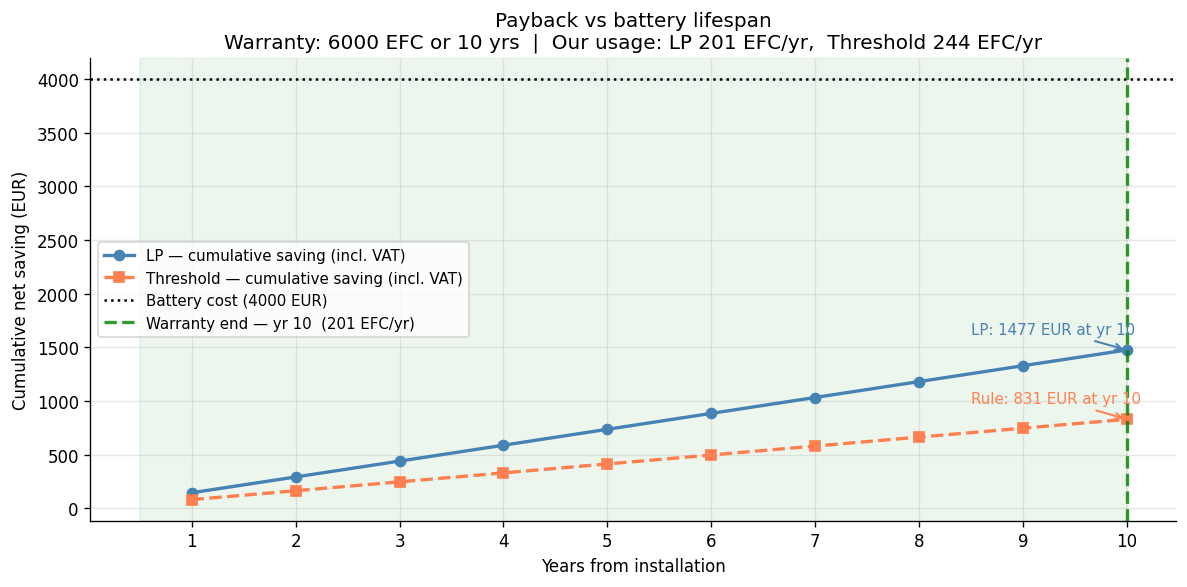

In [20]:
# ── Manufacturer warranty parameters ─────────────────────────────────────────
WARRANTY_EFC   = 6000   # guaranteed EFC (BYD LFP 10 kWh typical; check your model's datasheet)
WARRANTY_YEARS = 10     # calendar warranty cap — whichever limit comes first

# ── EFC per year from backtest ────────────────────────────────────────────────
# cost_degradation = DEG * kWh_charged  →  kWh_charged = cost_degradation / DEG
n_bt = bt_lp['year'].nunique()

kWh_yr_lp   = bt_lp['cost_degradation'].sum()   / DEG / n_bt
kWh_yr_rule = bt_rule['cost_degradation'].sum() / DEG / n_bt

efc_yr_lp   = kWh_yr_lp   / S_MAX
efc_yr_rule = kWh_yr_rule / S_MAX

# Cycle-limited lifespan = how many years until we hit WARRANTY_EFC
life_cycle_lp   = WARRANTY_EFC / efc_yr_lp
life_cycle_rule = WARRANTY_EFC / efc_yr_rule

# Actual lifespan = the earlier of cycle limit and calendar warranty
life_lp   = min(life_cycle_lp,   WARRANTY_YEARS)
life_rule = min(life_cycle_rule, WARRANTY_YEARS)

# ── Print summary ─────────────────────────────────────────────────────────────
print(f"Warranty: {WARRANTY_EFC} EFC  or  {WARRANTY_YEARS} years (whichever comes first)")
print()
print(f"{'':38s}  {'LP':>8}  {'Threshold':>10}")
print("-" * 62)
print(f"{'kWh charged per year':38s}  {kWh_yr_lp:8.0f}  {kWh_yr_rule:10.0f}")
print(f"{'EFC per year':38s}  {efc_yr_lp:8.1f}  {efc_yr_rule:10.1f}")
print(f"{'Cycle-limited lifespan (years)':38s}  {life_cycle_lp:8.1f}  {life_cycle_rule:10.1f}")
print(f"{'Actual lifespan — calendar cap (years)':38s}  {life_lp:8.1f}  {life_rule:10.1f}")
print()

# ── Payback vs lifespan verdict ───────────────────────────────────────────────
def verdict(life, pb, label):
    if pb is None or pb > life:
        pb_str = f"year {pb}" if pb else f">{PROJECTION_YEARS} yrs"
        print(f"{label}  payback {pb_str}  ✗  battery warranty ends at year {life:.0f}"
              f"  →  does NOT pay off within warranty")
    else:
        print(f"{label}  payback year {pb}  ✓  battery lasts {life:.0f} yrs"
              f"  →  {life - pb:.0f} yrs of profit after payback")

verdict(life_lp,   pb_lp,   "LP:        ")
verdict(life_rule, pb_rule, "Threshold: ")

# ── Chart: cumulative saving + battery cost + warranty window ─────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(years, lp_cumul,   marker='o', color='steelblue', lw=2,
        label=f'LP — cumulative saving (incl. VAT)')
ax.plot(years, rule_cumul, marker='s', color='coral',     lw=2, ls='--',
        label=f'Threshold — cumulative saving (incl. VAT)')
ax.axhline(BATTERY_COST, color='black', lw=1.5, ls=':',
           label=f'Battery cost ({BATTERY_COST} EUR)')

# Shade the warranty period and mark its end
warranty_end = min(life_lp, PROJECTION_YEARS)
ax.axvspan(years[0] - 0.5, warranty_end, alpha=0.07, color='green')
ax.axvline(warranty_end, color='green', lw=2, ls='--', alpha=0.8,
           label=f'Warranty end — yr {life_lp:.0f}  ({efc_yr_lp:.0f} EFC/yr)')

# Annotate saving at warranty end
for cumul, color, label in [
    (lp_cumul,   'steelblue', 'LP'),
    (rule_cumul, 'coral',     'Rule'),
]:
    # find the saving at the last year within warranty
    idx = min(int(warranty_end) - 1, len(cumul) - 1)
    ax.annotate(f'{label}: {cumul[idx]:.0f} EUR at yr {idx+1}',
                xy=(idx + 1, cumul[idx]),
                xytext=(idx + 1 - 1.5, cumul[idx] + 150),
                fontsize=9, color=color,
                arrowprops=dict(arrowstyle='->', color=color, lw=1.2))

ax.set_xlabel('Years from installation')
ax.set_ylabel('Cumulative net saving (EUR)')
ax.set_title(
    f'Payback vs battery lifespan\n'
    f'Warranty: {WARRANTY_EFC} EFC or {WARRANTY_YEARS} yrs  |  '
    f'Our usage: LP {efc_yr_lp:.0f} EFC/yr,  Threshold {efc_yr_rule:.0f} EFC/yr'
)
ax.set_xticks(years)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### 7d. Consumption sensitivity — does a bigger household change the economics?

Higher consumption → battery can discharge more each day → more EFC/year → faster payback.
But there is a ceiling: once daily load exceeds battery capacity, adding more consumption no longer helps.

Tested range covers a typical household (3 500 kWh) up to a household with an EV (≈9 000 kWh).

Loaded from ..\results\consumption_sensitivity.csv

           saving_yr (LP) saving_yr (Threshold) efc_per_year (LP) efc_per_year (Threshold) payback_simple (LP) payback_simple (Threshold) pays_off (LP) pays_off (Threshold)
annual_kwh                                                                                                                                                                  
2000                 92.0                  45.0             119.3                    150.8                43.6                       89.0         False                False
3500                146.0                  82.0             200.8                    244.0                27.4                       48.7         False                False
5000                192.0                 116.0             264.6                    303.1                20.8                       34.6         False                False
7000                243.0                 133.0             336.3                  

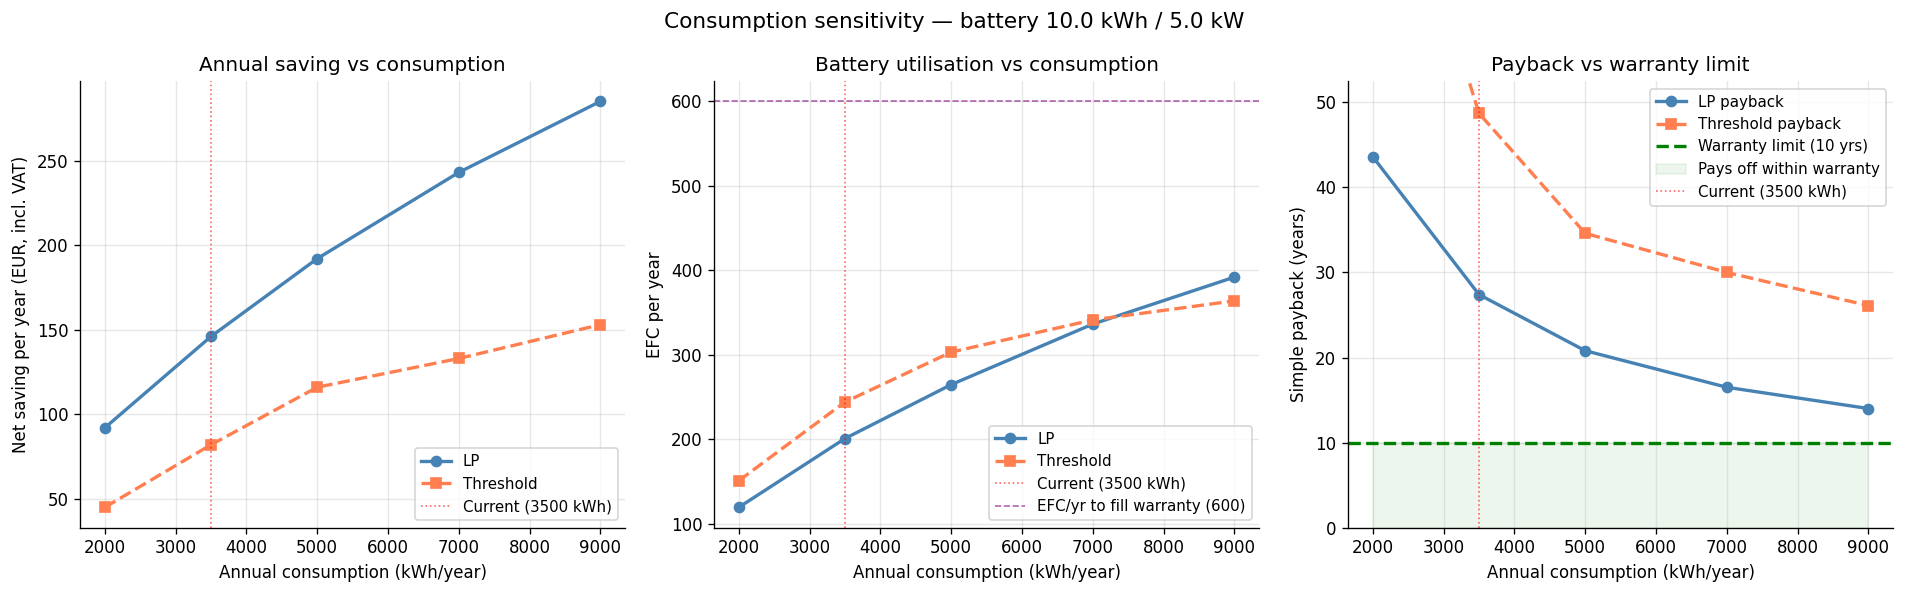

In [ ]:
KWH_RANGE = [2000, 3500, 5000, 7000, 9000]  # annual household consumption to test
BASE_KWH  = 3500  # load_clean.csv baseline

RECOMPUTE = True  # False → load saved CSV

out_path = Path('../results/consumption_sensitivity.csv')

if RECOMPUTE:
    rows = []
    for kwh in KWH_RANGE:
        load_s = load.copy()
        load_s['consumption'] = load['consumption'] * (kwh / BASE_KWH)

        bt_l = backtest(prices, load_s, S_MAX, P_MAX, ETA_C, ETA_D, S_INIT,
                        strategy='lp', binary=False, deg_cost=DEG, S_min=S_MIN)
        bt_r = backtest(prices, load_s, S_MAX, P_MAX, ETA_C, ETA_D, S_INIT,
                        strategy='threshold', deg_cost=DEG, S_min=S_MIN)
        print(f"{kwh} kWh/yr done")

        n = bt_l['year'].nunique()
        for strategy, bt in [('LP', bt_l), ('Threshold', bt_r)]:
            saving_yr    = bt['saving_net'].sum() / n * PRICE_SCALE_FACTOR
            kWh_yr       = bt['cost_degradation'].sum() / DEG / n
            efc_yr       = kWh_yr / S_MAX
            life_cycle   = WARRANTY_EFC / efc_yr if efc_yr > 0 else 9999
            life         = min(life_cycle, WARRANTY_YEARS)
            pb_simple    = BATTERY_COST / saving_yr if saving_yr > 0 else 9999
            rows.append({
                'annual_kwh':      kwh,
                'strategy':        strategy,
                'saving_yr':       round(saving_yr,  0),
                'efc_per_year':    round(efc_yr,      1),
                'life_cycle_yrs':  round(life_cycle,  1),
                'life_yrs':        round(life,         1),
                'payback_simple':  round(pb_simple,   1),
                'pays_off':        pb_simple <= life,
            })

    df_kwh = pd.DataFrame(rows)
    df_kwh.to_csv(out_path, index=False)
    print(f"Saved to {out_path.resolve()}")
else:
    df_kwh = pd.read_csv(out_path)
    print(f"Loaded from {out_path}")

# ── Summary table ─────────────────────────────────────────────────────────────
print()
pivot = df_kwh.pivot(index='annual_kwh', columns='strategy',
                     values=['saving_yr', 'efc_per_year', 'payback_simple', 'pays_off'])
pivot.columns = [f"{v} ({s})" for v, s in pivot.columns]
print(pivot.to_string())

# ── Charts ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.subplots_adjust(wspace=0.35)

lp_rows   = df_kwh[df_kwh['strategy'] == 'LP']
rule_rows = df_kwh[df_kwh['strategy'] == 'Threshold']
xs = KWH_RANGE

# Chart 1 — net saving per year
ax = axes[0]
ax.plot(xs, lp_rows['saving_yr'].values,   marker='o', color='steelblue', lw=2, label='LP')
ax.plot(xs, rule_rows['saving_yr'].values, marker='s', color='coral',     lw=2, ls='--', label='Threshold')
ax.axvline(ANNUAL_KWH, color='red', lw=1, ls=':', alpha=0.6, label=f'Current ({ANNUAL_KWH} kWh)')
ax.set_xlabel('Annual consumption (kWh/year)')
ax.set_ylabel('Net saving per year (EUR, incl. VAT)')
ax.set_title('Annual saving vs consumption')
ax.legend(fontsize=9)

# Chart 2 — EFC per year
ax = axes[1]
ax.plot(xs, lp_rows['efc_per_year'].values,   marker='o', color='steelblue', lw=2, label='LP')
ax.plot(xs, rule_rows['efc_per_year'].values, marker='s', color='coral',     lw=2, ls='--', label='Threshold')
ax.axvline(ANNUAL_KWH, color='red', lw=1, ls=':', alpha=0.6, label=f'Current ({ANNUAL_KWH} kWh)')
ax.axhline(WARRANTY_EFC / WARRANTY_YEARS, color='purple', lw=1, ls='--', alpha=0.6,
           label=f'EFC/yr to fill warranty ({WARRANTY_EFC/WARRANTY_YEARS:.0f})')
ax.set_xlabel('Annual consumption (kWh/year)')
ax.set_ylabel('EFC per year')
ax.set_title('Battery utilisation vs consumption')
ax.legend(fontsize=9)

# Chart 3 — simple payback vs warranty
ax = axes[2]
ax.plot(xs, lp_rows['payback_simple'].values,   marker='o', color='steelblue', lw=2, label='LP payback')
ax.plot(xs, rule_rows['payback_simple'].values, marker='s', color='coral',     lw=2, ls='--', label='Threshold payback')
ax.axhline(WARRANTY_YEARS, color='green', lw=2, ls='--',
           label=f'Warranty limit ({WARRANTY_YEARS} yrs)')
ax.fill_between(xs, 0, WARRANTY_YEARS, alpha=0.07, color='green', label='Pays off within warranty')
ax.axvline(ANNUAL_KWH, color='red', lw=1, ls=':', alpha=0.6, label=f'Current ({ANNUAL_KWH} kWh)')
ax.set_xlabel('Annual consumption (kWh/year)')
ax.set_ylabel('Simple payback (years)')
ax.set_title('Payback vs warranty limit')
ax.set_ylim(0, max(lp_rows['payback_simple'].max(), 50) * 1.05)
ax.legend(fontsize=9)

plt.suptitle(f'Consumption sensitivity — battery {S_MAX} kWh / {P_MAX} kW', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Best & worst days

Which days did the battery save the most / least?
Key driver: `price_range` = max − min price within a day — the wider the spread, the more the battery can earn.

── Top 10 best days (LP net saving) ─────────────────────────
             weekday  season  price_range  price_mean  cost_baseline  saving_net saving_%
date                                                                                     
2025-05-11    Sunday  Spring        0.589      -0.010          -0.48        3.94        —
2025-04-27    Sunday  Spring        0.391       0.029           0.05        2.30        —
2022-08-28    Sunday  Summer        0.680       0.408           3.85        1.99    51.8%
2022-07-25    Monday  Summer        0.241       0.295           2.94        1.99    67.6%
2022-03-08   Tuesday  Spring        0.545       0.462           4.30        1.97    45.8%
2022-08-13  Saturday  Summer        0.485       0.362           3.75        1.89    50.4%
2022-03-14    Monday  Spring        0.232       0.280           2.66        1.77    66.8%
2022-07-24    Sunday  Summer        0.483       0.239           2.12        1.75    82.4%
2022-12-13   Tuesday  Winter        0.

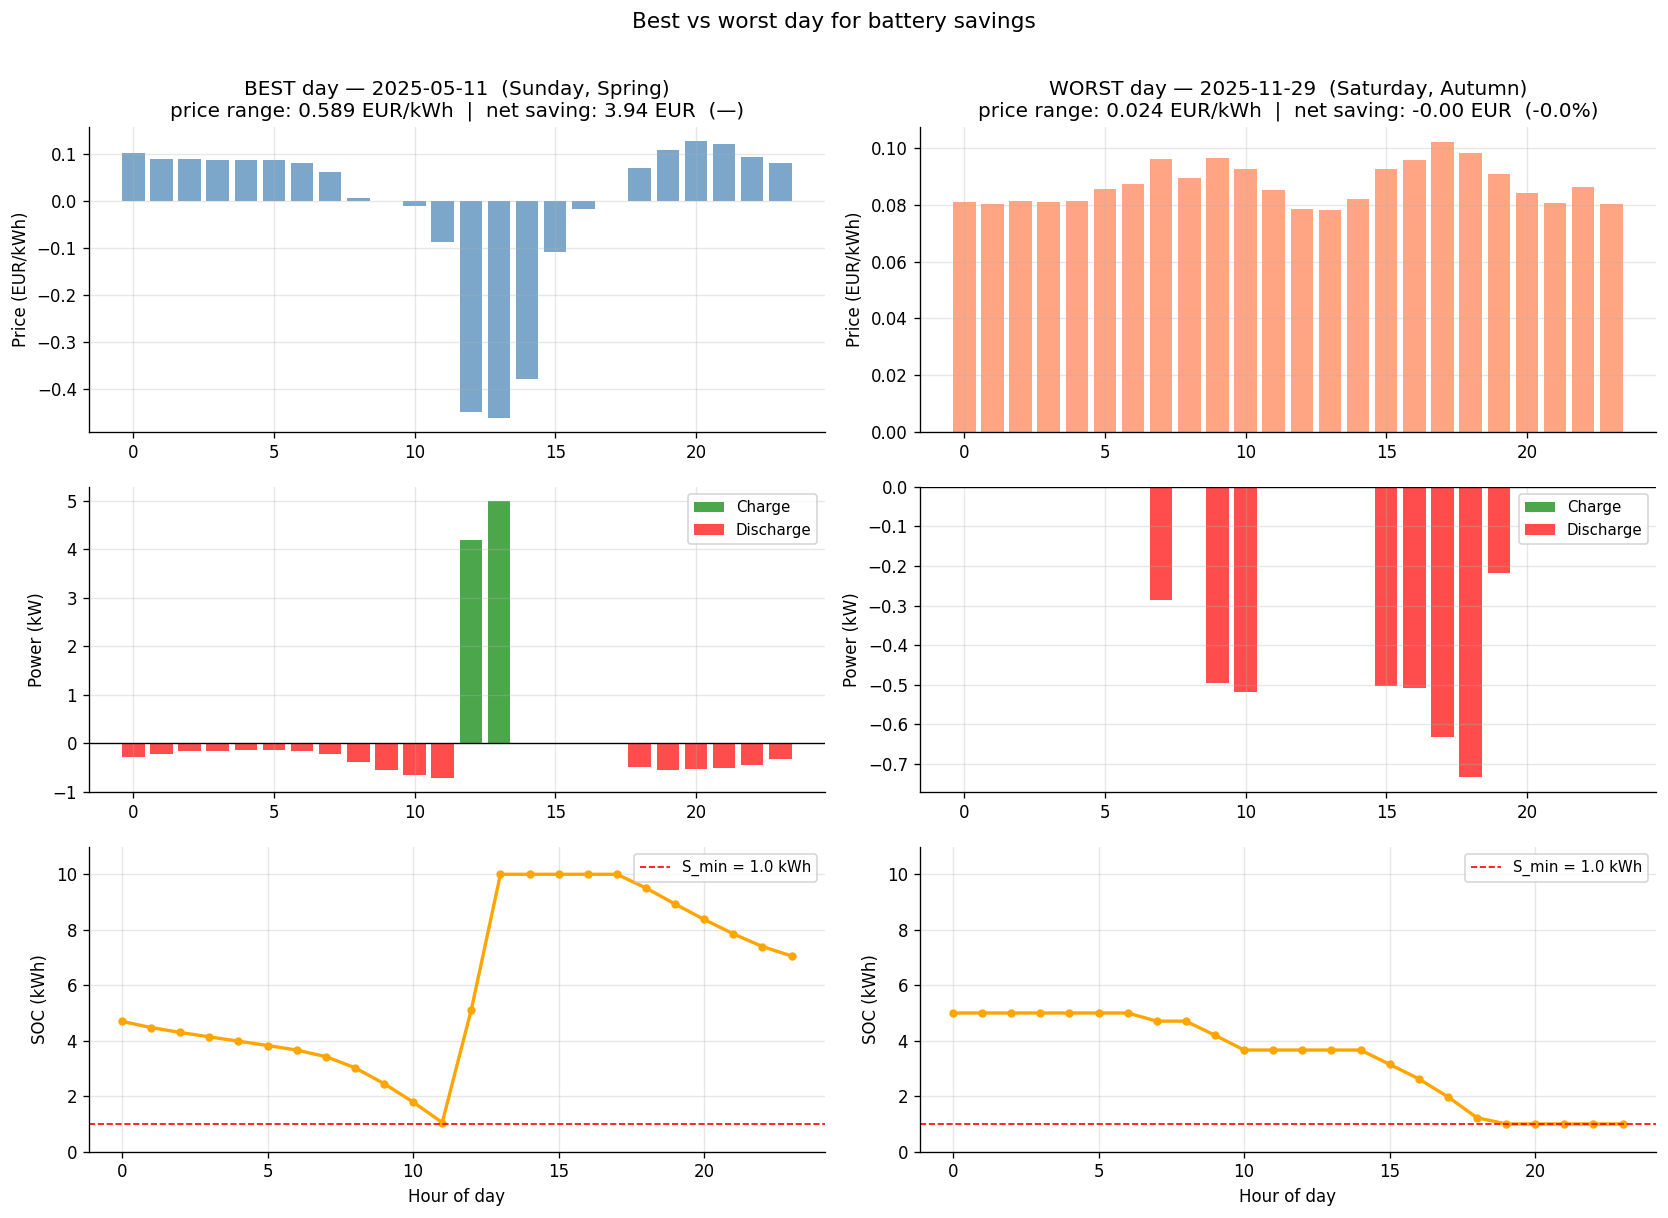

In [10]:
# ── Daily price statistics ────────────────────────────────────────────────────
prices_naive = prices.copy()
prices_naive.index = prices_naive.index.tz_localize(None)
p_stats = (prices_naive['price_eur_kwh']
           .groupby(prices_naive.index.date)
           .agg(price_min='min', price_max='max', price_mean='mean'))
p_stats['price_range'] = p_stats['price_max'] - p_stats['price_min']
p_stats.index = pd.to_datetime(p_stats.index)

# ── Enrich bt_lp with price stats and calendar info ───────────────────────────
def season(month):
    return {12:'Winter',1:'Winter',2:'Winter',
            3:'Spring',4:'Spring',5:'Spring',
            6:'Summer',7:'Summer',8:'Summer'}.get(month, 'Autumn')

bt = bt_lp.copy()
bt.index = pd.to_datetime(bt.index)
bt = bt.join(p_stats)
bt['weekday'] = bt.index.day_name()
bt['season']  = bt.index.month.map(season)

# saving_% is only meaningful when baseline cost is clearly positive
# (negative or near-zero baseline → extreme %, e.g. on negative-price days)
MIN_BASELINE = 0.05  # EUR — below this threshold saving_% is not shown
bt['saving_%'] = bt.apply(
    lambda r: f"{r['saving_net'] / r['cost_baseline'] * 100:.1f}%"
              if r['cost_baseline'] > MIN_BASELINE else '—',
    axis=1
)

COLS = ['weekday', 'season', 'price_range', 'price_mean',
        'cost_baseline', 'saving_net', 'saving_%']

def fmt(df):
    df = df.copy()
    df['price_range']   = df['price_range'].round(3)
    df['price_mean']    = df['price_mean'].round(3)
    df['cost_baseline'] = df['cost_baseline'].round(2)
    df['saving_net']    = df['saving_net'].round(2)
    return df

# ── Top 10 best days ──────────────────────────────────────────────────────────
top10 = fmt(bt.nlargest(10, 'saving_net')[COLS])
print("── Top 10 best days (LP net saving) ─────────────────────────")
print(top10.to_string())

# ── Top 10 worst days ─────────────────────────────────────────────────────────
bot10 = fmt(bt.nsmallest(10, 'saving_net')[COLS])
print("\n── Top 10 worst days (LP net saving) ────────────────────────")
print(bot10.to_string())

# ── Price profile comparison: best vs worst day ───────────────────────────────
best_date  = bt['saving_net'].idxmax()
worst_date = bt['saving_net'].idxmin()

def day_data(date):
    p = prices[prices.index.date == date.date()]['price_eur_kwh'].values
    l = load[load.index.date == date.date()]['consumption'].values
    res = optimize_day(p, l, S_MAX, P_MAX, ETA_C, ETA_D, S_INIT,
                       cyclic=False, binary=True, deg_cost=DEG, S_min=S_MIN)
    return p, l, res

p_best,  l_best,  res_best  = day_data(best_date)
p_worst, l_worst, res_worst = day_data(worst_date)

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=False)

for col, (date, p, res, label) in enumerate([
    (best_date,  p_best,  res_best,  'BEST'),
    (worst_date, p_worst, res_worst, 'WORST'),
]):
    saving    = bt.loc[date, 'saving_net']
    price_rng = bt.loc[date, 'price_range']
    pct       = bt.loc[date, 'saving_%']
    hours     = range(len(p))
    color     = 'steelblue' if col == 0 else 'coral'

    axes[0, col].bar(hours, p, color=color, alpha=0.7)
    axes[0, col].set_ylabel('Price (EUR/kWh)')
    axes[0, col].set_title(
        f'{label} day — {date.date()}  ({bt.loc[date,"weekday"]}, {bt.loc[date,"season"]})\n'
        f'price range: {price_rng:.3f} EUR/kWh  |  net saving: {saving:.2f} EUR  ({pct})')

    axes[1, col].bar(hours, res['c'], color='green', alpha=0.7, label='Charge')
    axes[1, col].bar(hours, [-x for x in res['d']], color='red', alpha=0.7, label='Discharge')
    axes[1, col].axhline(0, color='black', lw=0.8)
    axes[1, col].set_ylabel('Power (kW)')
    axes[1, col].legend(fontsize=9)

    axes[2, col].plot(hours, res['s'], color='orange', lw=2, marker='o', ms=4)
    axes[2, col].axhline(S_MIN, color='red', lw=1, ls='--', label=f'S_min = {S_MIN} kWh')
    axes[2, col].set_ylabel('SOC (kWh)')
    axes[2, col].set_xlabel('Hour of day')
    axes[2, col].set_ylim(0, S_MAX + 1)
    axes[2, col].legend(fontsize=9)

plt.suptitle('Best vs worst day for battery savings', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 9. Conclusions

### What was modelled
A home battery (BYD LFP 10 kWh / 5 kW) operated on the Belgian EPEX day-ahead spot price
over a 4-year backtest (2022–2025) for a synthetic H0 household profile (3 500 kWh/year).
Two strategies were compared: **LP optimisation** (optimal, slow) and a **threshold rule** (heuristic, fast).

---

### Key findings

| Finding | Result |
|---|---|
| LP net saving — 4-year average | ~120 EUR/year (incl. 21 % VAT) |
| Threshold net saving — 4-year average | ~68 EUR/year (incl. 21 % VAT) |
| LP advantage over threshold | ~52 EUR/year (~76 %) |
| 2022 (energy crisis) vs 2023–2025 (normal) | 274 EUR/yr vs 103 EUR/yr — crisis inflates the average |
| Battery utilisation | ~200 EFC/year — far below the 600 EFC/yr needed to fill the cycle warranty |
| Simple payback — full period average | ~27 years |
| Simple payback — normal market only | ~39 years |
| Payback within 10-year warranty? | **No** — at any tested consumption level (2 000–9 000 kWh/yr) |

---

### Why the battery does not pay off (pure arbitrage)

1. **Small price spread** — the EPEX hourly spread in normal years (2023–2025) averages
   ~0.05–0.10 EUR/kWh. After efficiency losses (η_rt ≈ 0.95) and degradation cost,
   the net gain per kWh shifted is small.
2. **Low household load limits discharge** — `d[t] ≤ load[t]` means the battery cannot
   sell to the grid. With 3 500 kWh/year (avg ~0.4 kWh/hr), the battery is often
   discharge-constrained regardless of P_max.
3. **2022 was an outlier** — the energy crisis produced exceptional price volatility.
   Using 2022 in the average flatters the payback estimate; the normal-market figure is
   the more conservative and realistic baseline.
4. **Calendar warranty caps lifespan at 10 years** — the battery is lightly cycled
   (~200 EFC/yr vs 6 000 EFC warranty), so the physical cycle limit is never reached.
   The binding constraint is the 10-year calendar warranty.

---

### Sensitivity analysis highlights

- **S_max**: savings grow with capacity but plateau around 10–12 kWh for this load profile.
- **S_min**: increasing the minimum SOC (depth-of-discharge protection) reduces savings
  roughly linearly; 10 % (1 kWh) is a reasonable trade-off.
- **P_max**: LP shows a monotone increase; threshold paradoxically drops (greedy rule
  fills the battery too fast). Trust the LP curve for P_max decisions.

---

### Limitations

- Synthetic H0 load profile — no real consumption peaks (EV, heat pump).
- EPEX spot prices only — no solar PV generation, no capaciteitstarief (peak-demand tariff).
- Static battery model — no calendar ageing of capacity over 10 years.
- VAT scaling is approximate — only VAT (21 %) applied; other levies ignored.

---

### When does a battery make economic sense in Belgium?

| Scenario | Payback estimate |
|---|---|
| Dynamic tariff, no solar *(this model)* | **> 27 years — does not pay off** |
| Dynamic tariff + flexible EV charging | ~15–20 years (estimate) |
| Solar PV + battery (self-consumption) | **~5–8 years** (typical) |
| Solar PV + battery + capaciteitstarief | ~4–6 years (typical) |

> The main economic driver for residential batteries in Belgium is **solar self-consumption**,
> not EPEX price arbitrage. Since the abolition of net metering for new PV installations (2024),
> storing excess solar production has become the primary use case.